This notebook is used for Data Cleaning, Preprocessing and Validation

In [1]:
import pandas as pd

In [2]:
books_df = pd.read_json("goodreads_books_children.json", lines = True) 
reviews_df = pd.read_json("goodreads_reviews_children.json", lines = True) 
interactions_df = pd.read_json("goodreads_interactions_children.json", lines = True) 

<h1> Data Cleaning and Preprocessing Summary </h1>

1. Standardise missing values
- strip whitespace in string columns
- convert pseudo-missing tokens to real NaN

2. Parse dates
- convert timestamp columns to datetime object with UTC (date_added, date_updated, read_at, started_at)

3. Recode rating fields 
- create has_rating (1/0), cleaned_rating (0s in rating --> NaN), positive_rating (1 if cleaned_rating >= 4, 0 otherwise, NaN if cleaned_rating is NaN)

In [3]:
import numpy as np
import pandas as pd

# Common placeholders that represent pseudo-missing values in string/object fields.
PLACEHOLDERS = {"none", "null", "n/a", "nan", "[]", "{}"}
TIMESTAMP_COLS = ["date_added", "date_updated", "read_at", "started_at"]


def object_columns(df: pd.DataFrame):
    return df.select_dtypes(include=["object", "string"]).columns.tolist()


def summarize_missing(df: pd.DataFrame, columns, label: str):
    summary_rows = []
    for col in columns:
        if col not in df.columns:
            summary_rows.append(
                {
                    "column": col,
                    "dtype": "<missing column>",
                    "missing_count": np.nan,
                    "missing_pct": np.nan,
                    "non_null_count": np.nan,
                }
            )
            continue

        missing_count = int(df[col].isna().sum())
        total = len(df)
        summary_rows.append(
            {
                "column": col,
                "dtype": str(df[col].dtype),
                "missing_count": missing_count,
                "missing_pct": round((missing_count / total) * 100, 2) if total else np.nan,
                "non_null_count": int(total - missing_count),
            }
        )

    summary_df = pd.DataFrame(summary_rows)
    print(f"\n{label}")
    print(summary_df.to_string(index=False))
    return summary_df


def normalize_string_series(series: pd.Series, placeholders=PLACEHOLDERS):
    # Only normalize true strings; keep non-string objects untouched.
    is_str = series.map(lambda x: isinstance(x, str))
    stripped = series.where(is_str, pd.NA).astype("string").str.strip()
    lowered = stripped.str.lower()

    pseudo_missing = stripped.eq("") | lowered.isin(placeholders)

    normalized = series.copy()
    normalized.loc[is_str] = stripped.loc[is_str]
    normalized.loc[is_str & pseudo_missing] = pd.NA
    return normalized


def clean_object_columns_to_nan(df: pd.DataFrame, placeholders=PLACEHOLDERS):
    cleaned = df.copy()
    cols = object_columns(cleaned)

    for col in cols:
        cleaned[col] = normalize_string_series(cleaned[col], placeholders=placeholders)

    return cleaned


def recode_rating_columns(df: pd.DataFrame, rating_col: str = "rating", prefix: str = ""):
    recoded = df.copy()

    if rating_col not in recoded.columns:
        raise ValueError(f"Column '{rating_col}' not found in DataFrame")

    original = pd.to_numeric(recoded[rating_col], errors="coerce")

    zeros_before = int(original.eq(0).sum(skipna=True))
    nonzero_before = int(original.ne(0).sum(skipna=True))

    # 0 means "not rated", so convert to missing
    cleaned_rating = original.mask(original.eq(0), np.nan)

    # Explicit rating exists or not
    has_rating = cleaned_rating.notna().astype("int8")

    # positive_rating should be:
    # 1 if cleaned_rating >= 4
    # 0 if cleaned_rating < 4 and non-missing
    # NaN if cleaned_rating is missing
    positive_rating = pd.Series(np.nan, index=recoded.index, dtype="float")
    rated_mask = cleaned_rating.notna()
    positive_rating.loc[rated_mask] = (cleaned_rating.loc[rated_mask] >= 4).astype("int8")

    has_col = f"{prefix}has_rating" if prefix else "has_rating"
    cleaned_col = f"{prefix}cleaned_rating" if prefix else "cleaned_rating"
    positive_col = f"{prefix}positive_rating" if prefix else "positive_rating"

    recoded[has_col] = has_rating
    recoded[cleaned_col] = cleaned_rating
    recoded[positive_col] = positive_rating

    total = len(recoded)
    positive_count_after = int(recoded[positive_col].eq(1).sum(skipna=True))
    positive_count_before = int(original.ge(4).sum(skipna=True))

    summary = pd.DataFrame(
        [
            {
                "stage": "before_recoding",
                "rows": total,
                "count_zeros": zeros_before,
                "count_nonzero_ratings": nonzero_before,
                "count_missing_cleaned_rating": np.nan,
                "count_missing_positive_rating": np.nan,
                "count_positive_rating": positive_count_before,
                "pct_positive_rating": round((positive_count_before / total) * 100, 2) if total else np.nan,
            },
            {
                "stage": "after_recoding",
                "rows": total,
                "count_zeros": int(recoded[cleaned_col].eq(0).sum(skipna=True)),
                "count_nonzero_ratings": int(recoded[cleaned_col].notna().sum()),
                "count_missing_cleaned_rating": int(recoded[cleaned_col].isna().sum()),
                "count_missing_positive_rating": int(recoded[positive_col].isna().sum()),
                "count_positive_rating": positive_count_after,
                "pct_positive_rating": round((positive_count_after / total) * 100, 2) if total else np.nan,
            },
        ]
    )

    return recoded, summary, {"has_col": has_col, "cleaned_col": cleaned_col, "positive_col": positive_col}


def clean_and_parse_timestamps(df: pd.DataFrame, timestamp_cols, placeholders=PLACEHOLDERS):
    cleaned = df.copy()
    rows = []
    failed_samples = {}

    for col in timestamp_cols:
        if col not in cleaned.columns:
            rows.append(
                {
                    "column": col,
                    "exists": False,
                    "empty_before": np.nan,
                    "na_before": np.nan,
                    "na_after_cleaning": np.nan,
                    "nat_after_parsing": np.nan,
                    "became_nat_after_parsing": np.nan,
                    "dtype_after": "<missing column>",
                }
            )
            continue

        raw = cleaned[col]
        is_str = raw.map(lambda x: isinstance(x, str))
        stripped = raw.where(is_str, pd.NA).astype("string").str.strip()

        empty_before = int(stripped.eq("").sum(skipna=True))
        na_before = int(raw.isna().sum())

        lowered = stripped.str.lower()
        is_pseudo_missing = stripped.eq("") | lowered.isin(placeholders)

        normalized = raw.copy()
        normalized.loc[is_str] = stripped.loc[is_str]
        normalized.loc[is_str & is_pseudo_missing] = pd.NA

        na_after_cleaning = int(pd.Series(normalized).isna().sum())

        parsed = pd.to_datetime(normalized, errors="coerce", format="mixed", utc=True)
        nat_after_parsing = int(parsed.isna().sum())
        became_nat = int(nat_after_parsing - na_after_cleaning)

        failed_mask = parsed.isna() & pd.Series(normalized).notna()
        failed_samples[col] = cleaned.loc[failed_mask, [col]].head(5).copy()
        if not failed_samples[col].empty:
            failed_samples[col].rename(columns={col: "original_value"}, inplace=True)

        cleaned[col] = parsed

        rows.append(
            {
                "column": col,
                "exists": True,
                "empty_before": empty_before,
                "na_before": na_before,
                "na_after_cleaning": na_after_cleaning,
                "nat_after_parsing": nat_after_parsing,
                "became_nat_after_parsing": became_nat,
                "dtype_after": str(cleaned[col].dtype),
            }
        )

    summary = pd.DataFrame(rows)
    return cleaned, summary, failed_samples


def preprocess_dataset_strings(df: pd.DataFrame, dataset_name: str, key_columns):
    print("\n" + "=" * 80)
    print(f"STRING PSEUDO-MISSING CLEANING: {dataset_name}")
    print("=" * 80)

    before = summarize_missing(df, key_columns, label="Before cleaning (key columns):")
    cleaned = clean_object_columns_to_nan(df)
    after = summarize_missing(cleaned, key_columns, label="After cleaning (key columns):")

    return cleaned, before, after

In [4]:
# 1) String pseudo-missing cleaning for all datasets
books_key_cols = ["description", "popular_shelves", "language_code", "format", "publisher", "series"]
interactions_key_cols = ["rating", "review_text_incomplete", "date_added", "date_updated", "read_at", "started_at"]
reviews_key_cols = ["review_text", "rating", "n_votes", "n_comments", "date_added", "date_updated", "read_at", "started_at"]

books_df_clean, books_before_missing, books_after_missing = preprocess_dataset_strings(books_df, "books_df", books_key_cols)
interactions_df_clean, interactions_before_missing, interactions_after_missing = preprocess_dataset_strings(
    interactions_df, "interactions_df", interactions_key_cols
)
reviews_df_clean, reviews_before_missing, reviews_after_missing = preprocess_dataset_strings(
    reviews_df, "reviews_df", reviews_key_cols
)


# 2) Rating recoding for interactions and reviews
print("\n" + "=" * 80)
print("RATING RECODING: interactions_df")
print("=" * 80)
interactions_df_clean, interactions_rating_summary, interactions_rating_cols = recode_rating_columns(
    interactions_df_clean, rating_col="rating"
)
print(interactions_rating_summary.to_string(index=False))

print("\n" + "=" * 80)
print("RATING RECODING: reviews_df")
print("=" * 80)
reviews_df_clean, reviews_rating_summary, reviews_rating_cols = recode_rating_columns(
    reviews_df_clean, rating_col="rating"
)
print(reviews_rating_summary.to_string(index=False))


# 3) Timestamp cleaning and parsing for interactions and reviews
print("\n" + "=" * 80)
print("TIMESTAMP CLEANING/PARSING: interactions_df")
print("=" * 80)
interactions_df_clean, interactions_ts_summary, interactions_failed_samples = clean_and_parse_timestamps(
    interactions_df_clean, TIMESTAMP_COLS
)
print(interactions_ts_summary.to_string(index=False))

print("\nSample failed parsing rows (interactions_df):")
for col, sample in interactions_failed_samples.items():
    if not sample.empty:
        print(f"\n{col}")
        print(sample.to_string(index=False))

print("\n" + "=" * 80)
print("TIMESTAMP CLEANING/PARSING: reviews_df")
print("=" * 80)
reviews_df_clean, reviews_ts_summary, reviews_failed_samples = clean_and_parse_timestamps(
    reviews_df_clean, TIMESTAMP_COLS
)
print(reviews_ts_summary.to_string(index=False))

print("\nSample failed parsing rows (reviews_df):")
for col, sample in reviews_failed_samples.items():
    if not sample.empty:
        print(f"\n{col}")
        print(sample.to_string(index=False))


print("\n" + "=" * 80)
print("PREPROCESSING COMPLETE")
print("=" * 80)
print("Cleaned outputs created: books_df_clean, interactions_df_clean, reviews_df_clean")


STRING PSEUDO-MISSING CLEANING: books_df

Before cleaning (key columns):
         column  dtype  missing_count  missing_pct  non_null_count
    description object              0          0.0          124082
popular_shelves object              0          0.0          124082
  language_code object              0          0.0          124082
         format object              0          0.0          124082
      publisher object              0          0.0          124082
         series object              0          0.0          124082

After cleaning (key columns):
         column  dtype  missing_count  missing_pct  non_null_count
    description object          15239        12.28          108843
popular_shelves object              0         0.00          124082
  language_code object          72496        58.43           51586
         format object          21039        16.96          103043
      publisher object          20145        16.24          103937
         series object  

<h1> Validation Checks </h1>

- dtype checks
- missingness checks
- key uniqueness/ duplicate chekcs
- rating sanity checks
- timestamp sanity checks
- categorical value checks
- text quality checks
- data validity / consistency checks

<h3> Checks for Dtype and Missingness </h3>

This check revealed some columns with high missingness and low-value to model training, which we opt to drop:
- books dataset: ["edition_information", "asin", "kindle_asin"]
- interactions dataset: ["review_text_incomplete"]

On inspection of Dtype, we also opt to convert the Dtypes of book publication data (["publication_day", "publication_month", "publication_year" ) and num_pages to numeric for ease of usability downstream.


In [6]:
PSEUDO_MISSING_TOKENS = {"", "none", "null", "n/a", "nan", "[]", "{}"}

def audit_missingness(df, name):
    """
    Comprehensive audit of missingness after cleaning.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe to audit
    name : str
        Name of the dataframe for display
    """
    print("\n" + "=" * 100)
    print(f"AUDIT REPORT: {name}")
    print("=" * 100)
    print(f"\nDataframe Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
    
    # Create comprehensive audit report
    audit_data = []
    
    for col in df.columns:
        missing_count = df[col].isna().sum()
        missing_pct = (missing_count / len(df)) * 100
        dtype = df[col].dtype
        
        # Pseudo-missing check
        if df[col].dtype == 'object':
            pseudo_missing_count = df[col].isin(PSEUDO_MISSING_TOKENS).sum()
        else:
            pseudo_missing_count = 0
        
        audit_data.append({
            'Column': col,
            'Dtype': str(dtype),
            'Missing_Count': missing_count,
            'Missing_%': f"{missing_pct:.2f}%",
            'Pseudo_Missing': pseudo_missing_count,
            'Total_Invalid': missing_count + pseudo_missing_count
        })
    
    audit_df = pd.DataFrame(audit_data)
    print(audit_df.to_string(index=False))
    
    # Summary statistics
    print(f"\n{'-' * 100}")
    print("SUMMARY STATISTICS:")
    print(f"{'-' * 100}")
    total_missing = audit_df['Missing_Count'].sum()
    total_pseudo = audit_df['Pseudo_Missing'].sum()
    total_cells = df.shape[0] * df.shape[1]
    
    print(f"Total cells: {total_cells:,}")
    print(f"Total missing values (NaN): {total_missing:,} ({(total_missing/total_cells)*100:.2f}%)")
    print(f"Total pseudo-missing values: {total_pseudo:,} ({(total_pseudo/total_cells)*100:.2f}%)")
    print(f"Total invalid values (NaN + Pseudo): {total_missing + total_pseudo:,} ({((total_missing + total_pseudo)/total_cells)*100:.2f}%)")
    
    # Columns with issues
    print(f"\n{'-' * 100}")
    print("COLUMNS WITH MISSING VALUES:")
    print(f"{'-' * 100}")
    cols_with_missing = audit_df[audit_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
    if len(cols_with_missing) > 0:
        print(cols_with_missing[['Column', 'Missing_Count', 'Missing_%', 'Pseudo_Missing']].to_string(index=False))
    else:
        print("✓ No missing values found")
    
    print(f"\n{'-' * 100}")
    print("COLUMNS WITH PSEUDO-MISSING VALUES:")
    print(f"{'-' * 100}")
    cols_with_pseudo = audit_df[audit_df['Pseudo_Missing'] > 0].sort_values('Pseudo_Missing', ascending=False)
    if len(cols_with_pseudo) > 0:
        print(cols_with_pseudo[['Column', 'Pseudo_Missing']].to_string(index=False))
    else:
        print("✓ No pseudo-missing values found")
    
    print("\n")
    return audit_df


# Run audit for all cleaned dataframes
print("\n" + "=" * 100)
print("COMPREHENSIVE MISSINGNESS AUDIT AFTER CLEANING")
print("=" * 100)

books_audit = audit_missingness(books_df_clean, "books_df_clean")
interactions_audit = audit_missingness(interactions_df_clean, "interactions_df_clean")
reviews_audit = audit_missingness(reviews_df_clean, "reviews_df_clean")


COMPREHENSIVE MISSINGNESS AUDIT AFTER CLEANING

AUDIT REPORT: books_df_clean

Dataframe Shape: 124082 rows × 29 columns

              Column   Dtype  Missing_Count Missing_%  Pseudo_Missing  Total_Invalid
                isbn  object          20199    16.28%               0          20199
  text_reviews_count   int64              0     0.00%               0              0
              series  object              0     0.00%               0              0
        country_code  object              0     0.00%               0              0
       language_code  object          72496    58.43%               0          72496
     popular_shelves  object              0     0.00%               0              0
                asin  object         117363    94.59%               0         117363
            is_ebook  object              0     0.00%               0              0
      average_rating float64              0     0.00%               0              0
         kindle_asin  object

<h3> Additional Cleaning Decisions after Dtype + Missingness Checks </h3>

<h5> Drop obvious low-value columns </h5>

In [7]:
# Drop low-value columns based on missingness audit
books_df_clean = books_df_clean.drop(columns=["edition_information", "asin", "kindle_asin"])
interactions_df_clean = interactions_df_clean.drop(columns=["review_text_incomplete"])

print("Dropped columns from books_df_clean: edition_information, asin, kindle_asin")
print("Dropped column from interactions_df_clean: review_text_incomplete")

Dropped columns from books_df_clean: edition_information, asin, kindle_asin
Dropped column from interactions_df_clean: review_text_incomplete


<h5> Drop columns non-relevant to model training </h5>

In [8]:
# Drop url, image_url, and work_id from books_df_clean
books_df_clean = books_df_clean.drop(columns=["url", "image_url", "work_id"])
print("Dropped columns from books_df_clean: url, image_url, work_id")

Dropped columns from books_df_clean: url, image_url, work_id


<h5> Convert Book publication data and num_pages to numeric </h5>

In [9]:
# Convert publication_day, publication_month, publication_year, and num_pages to numeric
to_numeric_cols = ["publication_day", "publication_month", "publication_year", "num_pages"]
for col in to_numeric_cols:
    books_df_clean[col] = pd.to_numeric(books_df_clean[col], errors="coerce")

print("Converted columns to numeric:", to_numeric_cols)

Converted columns to numeric: ['publication_day', 'publication_month', 'publication_year', 'num_pages']


<h3>Rating Sanity Checks</h3>

The rating sanity checks show that the recoding logic was applied correctly in both the interactions and reviews datasets. cleaned_rating contains no zero values, and there are no inconsistencies between has_rating, cleaned_rating, and positive_rating. This confirms that rating = 0 was successfully treated as “not rated” rather than a true score.

The cleaned rating distributions are concentrated at the upper end of the scale, with ratings of 4 and 5 being the most frequent in both datasets. Lower ratings are comparatively less common, indicating a positively skewed rating pattern. Missing cleaned_rating values are much more common in the interactions dataset than in the reviews dataset, which is expected since not all interactions include an explicit rating.


RATING SANITY CHECKS: interactions_df_clean
cleaned_rating has 0 zeros.
Rows where has_rating does not match cleaned_rating non-missing: 0
Rows where positive_rating==1 but cleaned_rating is missing or not positive: 0

cleaned_rating value counts:
cleaned_rating
1.0      70708
2.0     300240
3.0    1440343
4.0    2189243
5.0    2383936
NaN    3674879
Name: count, dtype: int64


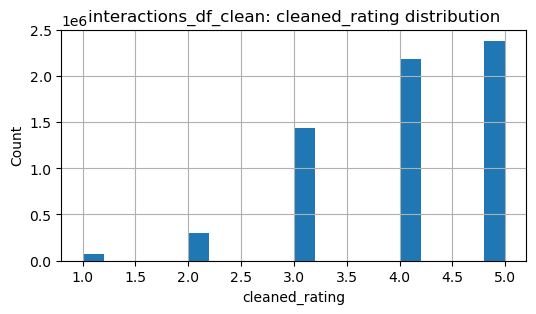


RATING SANITY CHECKS: reviews_df_clean
cleaned_rating has 0 zeros.
Rows where has_rating does not match cleaned_rating non-missing: 0
Rows where positive_rating==1 but cleaned_rating is missing or not positive: 0

cleaned_rating value counts:
cleaned_rating
1.0     10726
2.0     40006
3.0    148210
4.0    253185
5.0    251400
NaN     31113
Name: count, dtype: int64


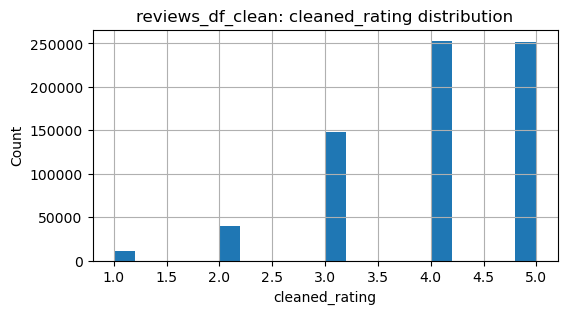

In [10]:
# Rating sanity checks for interactions_df_clean and reviews_df_clean
import matplotlib.pyplot as plt

for df_name, df in [("interactions_df_clean", interactions_df_clean), ("reviews_df_clean", reviews_df_clean)]:
    print(f"\n{'='*40}\nRATING SANITY CHECKS: {df_name}\n{'='*40}")
    # 1. cleaned_rating has no zeros
    if "cleaned_rating" in df.columns:
        zero_ratings = (df["cleaned_rating"] == 0).sum()
        print(f"cleaned_rating has {zero_ratings} zeros.")
    else:
        print("cleaned_rating column not found.")
    
    # 2. has_rating matches whether cleaned_rating is non-missing
    if "cleaned_rating" in df.columns and "has_rating" in df.columns:
        mismatch = (df["has_rating"] != df["cleaned_rating"].notna().astype(int)).sum()
        print(f"Rows where has_rating does not match cleaned_rating non-missing: {mismatch}")
    else:
        print("cleaned_rating or has_rating column not found.")
    
    # 3. positive_rating is only derived from cleaned_rating
    if "cleaned_rating" in df.columns and "positive_rating" in df.columns:
        # Check if positive_rating is 1 only when cleaned_rating > 0 (or > threshold)
        pos_rating_invalid = df[(df["positive_rating"] == 1) & ((df["cleaned_rating"].isna()) | (df["cleaned_rating"] <= 0))]
        print(f"Rows where positive_rating==1 but cleaned_rating is missing or not positive: {len(pos_rating_invalid)}")
    else:
        print("cleaned_rating or positive_rating column not found.")
    
    # 4. Distribution of ratings
    rating_col = None
    for col in ["cleaned_rating", "rating", "cleaned_rating"]:
        if col in df.columns:
            rating_col = col
            break
    if rating_col:
        print(f"\n{rating_col} value counts:")
        print(df[rating_col].value_counts(dropna=False).sort_index())
        plt.figure(figsize=(6,3))
        df[rating_col].hist(bins=20)
        plt.title(f"{df_name}: {rating_col} distribution")
        plt.xlabel(rating_col)
        plt.ylabel("Count")
        plt.show()
    else:
        print("No rating column found for distribution plot.")

<h3> Timestamp Sanity Checks </h3>

This check revealed some issues that we opt not to handle directly by dropping rows or creating supplementary flags, but note for feature engineering downstream:

</br>
1. Rows where date_added > date_updated

- Interactions 12636 (0.13%)
- Reviews 972 (0.13%)
- Logically inconsistent, since a record should not usually be updated before it is added
- Likely due to logging, ingestion, or export inconsistencies

<b> To handle this issue, we opt not to drop the rows, rather taking note to use date_added as the primary event timestamp downstream </b>

</br>
2. Rows where started_at > read_at

- Interactions 198 (0.00%)
- Reviews 18 (0.00%)
- Logically inconsistent for reading progression
- Negligible relative to dataset size

<b> To handle this issue, we opt not to drop the rows. Instead, any duration-based feature created downstream derived from started_at and read_at should just be treated as invalid or missing for these cases. </b>

</br>
3. Rows with read_at present but started_at missing

- Interactions 968958 (9.63%)
- Reviews 290149 (39.50%)
- These rows suggest that users marked a book as read without recording when they started it
- As a result, reading duration cannot be computed

<b> To handle this issue, we opt not to drop the rows. Instead, these rows will just have NaN values for any duration-based feature created downstream. </b>

</br>
4. Rows with started_at present but read_at missing

- Interactions 71792 (0.71%) 
- Reviews 4321 (0.59%)
- Indicates the user recorded that they started the book but did not mark it as finished
- Potentially useful for unfinished-reading behavior features

<b> To handle this issue, we opt not to drop the rows. Instead, these rows will just have NaN values for any duration-based feature created downstream. </b>

</br>
5. NaT counts

- date_added and date_updated are much more complete and suitable for event-time logic
- read_at and started_at are sparse, so they should be treated as optional behavioral timestamps rather than core timeline fields

In [11]:
# Timestamp sanity checks for interactions_df_clean and reviews_df_clean
for df_name, df in [("interactions_df_clean", interactions_df_clean), ("reviews_df_clean", reviews_df_clean)]:
    print(f"\n{'='*40}\nTIMESTAMP SANITY CHECKS: {df_name}\n{'='*40}")
    total_rows = len(df)
    # 1. date_added <= date_updated where both exist
    if "date_added" in df.columns and "date_updated" in df.columns:
        mask = df["date_added"].notna() & df["date_updated"].notna()
        invalid = (df.loc[mask, "date_added"] > df.loc[mask, "date_updated"]).sum()
        pct = (invalid / total_rows) * 100 if total_rows else 0
        print(f"Rows where date_added > date_updated: {invalid} ({pct:.2f}%)")
    else:
        print("date_added or date_updated column not found.")
    # 2. started_at <= read_at where both exist
    if "started_at" in df.columns and "read_at" in df.columns:
        mask = df["started_at"].notna() & df["read_at"].notna()
        invalid = (df.loc[mask, "started_at"] > df.loc[mask, "read_at"]).sum()
        pct = (invalid / total_rows) * 100 if total_rows else 0
        print(f"Rows where started_at > read_at: {invalid} ({pct:.2f}%)")
    else:
        print("started_at or read_at column not found.")
    # 3. rows with read_at present but started_at missing
    if "started_at" in df.columns and "read_at" in df.columns:
        count = ((df["read_at"].notna()) & (df["started_at"].isna())).sum()
        pct = (count / total_rows) * 100 if total_rows else 0
        print(f"Rows with read_at present but started_at missing: {count} ({pct:.2f}%)")
    # 4. rows with started_at present but read_at missing
        count2 = ((df["started_at"].notna()) & (df["read_at"].isna())).sum()
        pct2 = (count2 / total_rows) * 100 if total_rows else 0
        print(f"Rows with started_at present but read_at missing: {count2} ({pct2:.2f}%)")
    # 5. count of NaT by timestamp column
    ts_cols = [col for col in df.columns if str(df[col].dtype).startswith("datetime")]
    for col in ts_cols:
        nat_count = df[col].isna().sum()
        pct_nat = (nat_count / total_rows) * 100 if total_rows else 0
        print(f"{col}: {nat_count} NaT values ({pct_nat:.2f}%)")


TIMESTAMP SANITY CHECKS: interactions_df_clean
Rows where date_added > date_updated: 12636 (0.13%)
Rows where started_at > read_at: 198 (0.00%)
Rows with read_at present but started_at missing: 968958 (9.63%)
Rows with started_at present but read_at missing: 71792 (0.71%)
date_added: 0 NaT values (0.00%)
date_updated: 0 NaT values (0.00%)
read_at: 8174608 NaT values (81.26%)
started_at: 9071774 NaT values (90.18%)

TIMESTAMP SANITY CHECKS: reviews_df_clean
Rows where date_added > date_updated: 972 (0.13%)
Rows where started_at > read_at: 18 (0.00%)
Rows with read_at present but started_at missing: 290149 (39.50%)
Rows with started_at present but read_at missing: 4321 (0.59%)
date_added: 0 NaT values (0.00%)
date_updated: 0 NaT values (0.00%)
read_at: 180187 NaT values (24.53%)
started_at: 466015 NaT values (63.43%)


<h3> Data Validity / Consistency Checks </h3>

In [12]:
def _print_count(label, mask, df, sample_cols=None, sample_n=5):
    total = len(df)
    cnt = int(mask.sum())
    pct = (cnt / total * 100) if total else 0
    print(f"- {label}: {cnt} ({pct:.4f}%)")
    if cnt > 0 and sample_cols:
        cols = [c for c in sample_cols if c in df.columns]
        if cols:
            print(df.loc[mask, cols].head(sample_n))

<h4> Books </h4>

Validity Check revealed some issues with regard to the book data:
- publication_year <= 1000: 27 rows	(0.0218%)
- publication_year in future: 16 rows (0.0129%)
- blank/meaningless title: 2 rows (0.0016%)
- num_pages <= 0: 456 rows (0.3675%)

Since the number of books affected by the first three issues is very small relative to the overall dataset size, we treat these as fatal row-level issues and drop the corresponding book records.

For the books affected by num_pages <= 0, we opt to treat invalid page count as a repairable field-level issue and convert num_pages to NaN for the affected rows. This allows us to preserve the rest of the book metadata — such as title, description, shelves, author, and rating-related information — which may still be useful for downstream recommendation modeling.

To maintain cross-dataset consistency, any book_id removed from the books dataset due to fatal row-level issues is also removed from the interactions and reviews datasets.

In [14]:
from datetime import datetime

print("\n[BOOKS: VALIDITY CHECKS]")

# ==================================================
# STEP 1: DETECT ISSUES
# ==================================================
books_issue_masks = {}

if "num_pages" in books_df_clean.columns:
    npages = pd.to_numeric(books_df_clean["num_pages"], errors="coerce")
    books_issue_masks["num_pages <= 0"] = npages.notna() & (npages <= 0)

if "publication_year" in books_df_clean.columns:
    current_year = datetime.now().year
    py = pd.to_numeric(books_df_clean["publication_year"], errors="coerce")
    books_issue_masks["publication_year <= 1000"] = py.notna() & (py <= 1000)
    books_issue_masks["publication_year in future"] = py.notna() & (py > current_year)

if "publication_month" in books_df_clean.columns:
    pm = pd.to_numeric(books_df_clean["publication_month"], errors="coerce")
    books_issue_masks["publication_month not in 1..12"] = pm.notna() & ~pm.between(1, 12)

if "publication_day" in books_df_clean.columns:
    pd_ = pd.to_numeric(books_df_clean["publication_day"], errors="coerce")
    books_issue_masks["publication_day not in 1..31"] = pd_.notna() & ~pd_.between(1, 31)

if "average_rating" in books_df_clean.columns:
    ar = pd.to_numeric(books_df_clean["average_rating"], errors="coerce")
    books_issue_masks["average_rating outside 0..5"] = ar.notna() & ~ar.between(0, 5)

if "ratings_count" in books_df_clean.columns:
    rc = pd.to_numeric(books_df_clean["ratings_count"], errors="coerce")
    books_issue_masks["ratings_count < 0"] = rc.notna() & (rc < 0)

if "text_reviews_count" in books_df_clean.columns:
    trc = pd.to_numeric(books_df_clean["text_reviews_count"], errors="coerce")
    books_issue_masks["text_reviews_count < 0"] = trc.notna() & (trc < 0)

if "is_ebook" in books_df_clean.columns:
    ie = books_df_clean["is_ebook"].astype(str).str.strip().str.lower()
    valid_is_ebook = {"0", "1", "false", "true", "no", "yes"}
    books_issue_masks["is_ebook outside expected categories"] = (
        books_df_clean["is_ebook"].notna() & ~ie.isin(valid_is_ebook)
    )

if "title" in books_df_clean.columns:
    title = books_df_clean["title"].astype(str).str.strip().str.lower()
    meaningless = {"", "na", "n/a", "none", "null", "unknown", "untitled"}
    books_issue_masks["blank/meaningless title"] = (
        books_df_clean["title"].isna() | title.isin(meaningless)
    )

# ==================================================
# STEP 2: DISPLAY RESULTS OF THE CHECKS
# ==================================================
books_issue_summary = pd.DataFrame(
    [
        {
            "issue": label,
            "count": int(mask.sum()),
            "pct_of_books": round(mask.mean() * 100, 4)
        }
        for label, mask in books_issue_masks.items()
    ]
).sort_values(by="count", ascending=False)

print("\nDetected book validity issues:")
display(books_issue_summary)

preview_cols = [
    col for col in
    ["book_id", "title", "publication_year", "publication_month", "publication_day", "num_pages"]
    if col in books_df_clean.columns
]

issue_previews = []
for label, mask in books_issue_masks.items():
    sample_df = books_df_clean.loc[mask, preview_cols].head(5).copy()
    if not sample_df.empty:
        sample_df.insert(0, "issue", label)
        issue_previews.append(sample_df)

if issue_previews:
    books_issue_preview_table = pd.concat(issue_previews, ignore_index=True)
    print("\nSample offending rows (up to 5 per issue):")
    display(books_issue_preview_table)
else:
    books_issue_preview_table = pd.DataFrame()
    print("\nNo offending rows found.")


[BOOKS: VALIDITY CHECKS]

Detected book validity issues:


,issue,count,pct_of_books
0,num_pages <= 0,456,0.3675
1,publication_year <= 1000,27,0.0218
2,publication_year in future,16,0.0129
9,blank/meaningless title,2,0.0016
3,publication_month not in 1..12,0,0.0000
4,publication_day not in 1..31,0,0.0000
5,average_rating outside 0..5,0,0.0000
6,ratings_count < 0,0,0.0000
7,text_reviews_count < 0,0,0.0000
8,is_ebook outside expected categories,0,0.0000



Sample offending rows (up to 5 per issue):


,issue,book_id,title,publication_year,publication_month,publication_day,num_pages
0,num_pages <= 0,428336,Fudge-A-Mania,2007.0,8.0,28.0,0.0
1,num_pages <= 0,1658285,"Curtain Call (Satin Slippers, #6)",1988.0,6.0,12.0,0.0
2,num_pages <= 0,5844470,"Little Lord Fauntleroy, with eBook",2008.0,10.0,27.0,0.0
3,num_pages <= 0,988939,"Ida B: ...and Her Plans to Maximize Fun, Avoid...",2004.0,8.0,24.0,0.0
4,num_pages <= 0,3775172,Abandoned,2000.0,9.0,28.0,0.0
5,publication_year <= 1000,25738667,Clutter Land,14.0,6.0,15.0,32.0
6,publication_year <= 1000,31327927,Astrid Lindgren,16.0,10.0,5.0,95.0
7,publication_year <= 1000,29568282,Starr and the High Seas Wedding Drama (Flower ...,16.0,6.0,14.0,80.0
8,publication_year <= 1000,24549781,Molly's Flowers,214.0,11.0,12.0,50.0
9,publication_year <= 1000,34209103,Mein Leben als Zucchini,207.0,1.0,NaN,240.0


In [15]:
print("\n[BOOKS: HANDLING]")

# ==================================================
# STEP 3: APPLY HANDLING SAFELY ON COPIES
# ==================================================
# Handling rules applied:
# - num_pages <= 0              -> set num_pages to NaN
# - publication_year <= 1000    -> drop row
# - publication_year in future  -> drop row
# - blank/meaningless title     -> drop row
#
# Output naming convention:
# - *_stage1 = datasets after books-handling step

books_df_stage1 = books_df_clean.copy()
interactions_df_stage1 = interactions_df_clean.copy()
reviews_df_stage1 = reviews_df_clean.copy()

# -----------------------------
# 3A. Apply field-level repair
# -----------------------------
repair_actions = []

if "num_pages <= 0" in books_issue_masks and "num_pages" in books_df_stage1.columns:
    affected_rows = int(books_issue_masks["num_pages <= 0"].sum())
    books_df_stage1.loc[books_issue_masks["num_pages <= 0"], "num_pages"] = pd.NA
    repair_actions.append(
        {
            "issue": "num_pages <= 0",
            "handling_applied": "set num_pages to NaN",
            "rows_affected": affected_rows
        }
    )

repair_actions_table = pd.DataFrame(repair_actions)

# -----------------------------
# 3B. Build fatal row-drop mask
# -----------------------------
fatal_drop_issues = [
    "publication_year <= 1000",
    "publication_year in future",
    "blank/meaningless title",
]

drop_row_mask = pd.Series(False, index=books_df_clean.index)

for issue in fatal_drop_issues:
    if issue in books_issue_masks:
        drop_row_mask |= books_issue_masks[issue]

drop_book_ids = set()
if "book_id" in books_df_clean.columns:
    drop_book_ids = set(
        books_df_clean.loc[drop_row_mask, "book_id"].dropna().tolist()
    )

# -----------------------------
# 3C. Remove fatal book rows across all datasets
# -----------------------------
books_before = len(books_df_clean)
interactions_before = len(interactions_df_clean)
reviews_before = len(reviews_df_clean)

books_df_stage1 = books_df_stage1.loc[~books_df_stage1["book_id"].isin(drop_book_ids)].copy()
interactions_df_stage1 = interactions_df_stage1.loc[~interactions_df_stage1["book_id"].isin(drop_book_ids)].copy()
reviews_df_stage1 = reviews_df_stage1.loc[~reviews_df_stage1["book_id"].isin(drop_book_ids)].copy()

# ==================================================
# STEP 4: OUTPUTS
# ==================================================
cross_dataset_removal_table = pd.DataFrame(
    {
        "dataset": ["books_df_clean", "interactions_df_clean", "reviews_df_clean"],
        "rows_before": [books_before, interactions_before, reviews_before],
        "rows_after": [len(books_df_stage1), len(interactions_df_stage1), len(reviews_df_stage1)],
        "rows_removed_due_to_fatal_book_issues": [
            books_before - len(books_df_stage1),
            interactions_before - len(interactions_df_stage1),
            reviews_before - len(reviews_df_stage1),
        ]
    }
)

print("\nRepair actions applied:")
display(
    repair_actions_table
    if not repair_actions_table.empty
    else pd.DataFrame({"message": ["No repair actions applied"]})
)

print("\nCross-dataset row removal summary:")
display(cross_dataset_removal_table)


[BOOKS: HANDLING]

Repair actions applied:


,issue,handling_applied,rows_affected
0,num_pages <= 0,set num_pages to NaN,456



Cross-dataset row removal summary:


,dataset,rows_before,rows_after,rows_removed_due_to_fatal_book_issues
0,books_df_clean,124082,124037,45
1,interactions_df_clean,10059349,10058584,765
2,reviews_df_clean,734640,734536,104


In [17]:
print("\n[INTERACTIONS: VALIDITY CHECKS]")

# ==================================================
# STEP 1: DETECT ISSUES
# ==================================================
# Use interactions_df_stage1 because this cell is executed before stage2 is created.
# It does NOT apply any handling yet.

interactions_issue_masks = {}

if "rating" in interactions_df_stage1.columns:
    ir = pd.to_numeric(interactions_df_stage1["rating"], errors="coerce")
    interactions_issue_masks["rating outside 0..5"] = ir.notna() & ~ir.between(0, 5)

if "cleaned_rating" in interactions_df_stage1.columns:
    cr = pd.to_numeric(interactions_df_stage1["cleaned_rating"], errors="coerce")
    interactions_issue_masks["cleaned_rating == 0"] = cr.notna() & (cr == 0)

if {"has_rating", "cleaned_rating"}.issubset(interactions_df_stage1.columns):
    has_rating_series = pd.to_numeric(interactions_df_stage1["has_rating"], errors="coerce")
    cleaned_rating_nonmissing = interactions_df_stage1["cleaned_rating"].notna()
    interactions_issue_masks["has_rating inconsistent with cleaned_rating"] = (
        ((has_rating_series == 1) & (~cleaned_rating_nonmissing))
        | ((has_rating_series == 0) & (cleaned_rating_nonmissing))
    )

if {"cleaned_rating", "positive_rating"}.issubset(interactions_df_stage1.columns):
    cr = pd.to_numeric(interactions_df_stage1["cleaned_rating"], errors="coerce")
    pr = pd.to_numeric(interactions_df_stage1["positive_rating"], errors="coerce")
    expected_positive = cr.ge(4)
    interactions_issue_masks["positive_rating inconsistent with cleaned_rating >= 4"] = (
        cr.notna() & (pr != expected_positive.astype(float))
    )

if "is_read" in interactions_df_stage1.columns:
    is_read_num = pd.to_numeric(interactions_df_stage1["is_read"], errors="coerce")
    interactions_issue_masks["is_read outside valid values {0,1}"] = (
        is_read_num.notna() & ~is_read_num.isin([0, 1])
    )

# ==================================================
# STEP 2: DISPLAY RESULTS OF THE CHECKS
# ==================================================
interactions_issue_summary = pd.DataFrame(
    [
        {
            "issue": label,
            "count": int(mask.sum()),
            "pct_of_interactions": round(mask.mean() * 100, 4)
        }
        for label, mask in interactions_issue_masks.items()
    ]
).sort_values(by="count", ascending=False)

print("\nDetected interaction validity issues:")
display(interactions_issue_summary)

preview_cols = [
    col for col in
    ["user_id", "book_id", "review_id", "rating", "cleaned_rating", "positive_rating", "has_rating", "is_read"]
    if col in interactions_df_stage1.columns
]

issue_previews = []
for label, mask in interactions_issue_masks.items():
    sample_df = interactions_df_stage1.loc[mask, preview_cols].head(5).copy()
    if not sample_df.empty:
        sample_df.insert(0, "issue", label)
        issue_previews.append(sample_df)

if issue_previews:
    interactions_issue_preview_table = pd.concat(issue_previews, ignore_index=True)
    print("\nSample offending rows (up to 5 per issue):")
    display(interactions_issue_preview_table)
else:
    interactions_issue_preview_table = pd.DataFrame()
    print("\nNo offending rows found.")


[INTERACTIONS: VALIDITY CHECKS]

Detected interaction validity issues:


,issue,count,pct_of_interactions
0,rating outside 0..5,0,0.0
1,cleaned_rating == 0,0,0.0
2,has_rating inconsistent with cleaned_rating,0,0.0
3,positive_rating inconsistent with cleaned_rati...,0,0.0
4,"is_read outside valid values {0,1}",0,0.0



No offending rows found.


<h4> Reviews </h4>

The review validity checks revealed three nonzero issues:
- empty review_text after cleaning: 162 rows (0.0221%)
- negative n_votes: 37 rows (0.0050%)
- negative n_comments: 1 row (0.0001%)

For rows with negative n_votes or n_comments, we treat these values as invalid and convert the affected fields to missing values (NaN), opting not to drop them because the review itself may still be usable. 

For reviews with empty review_text, we retain the rows in the reviews dataset, but exclude them from any text-based feature engineering steps such as review embeddings or sentiment extraction. To do so, we create a flag indicating whether a review has usable text, and only rows with usable review text are passed into downstream text-feature pipelines.

In [18]:
print("\n[REVIEWS: VALIDITY CHECKS]")

# ==================================================
# STEP 1: DETECT ISSUES
# ==================================================
# Use reviews_df_stage1 so earlier book-based filtering is preserved.

reviews_issue_masks = {}

if "rating" in reviews_df_stage1.columns:
    rr = pd.to_numeric(reviews_df_stage1["rating"], errors="coerce")
    reviews_issue_masks["rating outside 0..5"] = rr.notna() & ~rr.between(0, 5)

if "review_text" in reviews_df_stage1.columns:
    reviews_issue_masks["empty review_text after cleaning"] = (
        reviews_df_stage1["review_text"].isna()
        | (reviews_df_stage1["review_text"].astype(str).str.strip() == "")
    )

review_text_dup_cols = [c for c in ["user_id", "book_id", "review_id", "review_text"] if c in reviews_df_stage1.columns]
if len(review_text_dup_cols) == 4:
    reviews_issue_masks["duplicated review_text for same [user_id, book_id, review_id]"] = (
        reviews_df_stage1.duplicated(subset=review_text_dup_cols, keep=False)
    )

if "n_votes" in reviews_df_stage1.columns:
    nv = pd.to_numeric(reviews_df_stage1["n_votes"], errors="coerce")
    reviews_issue_masks["n_votes < 0"] = nv.notna() & (nv < 0)

if "n_comments" in reviews_df_stage1.columns:
    nc = pd.to_numeric(reviews_df_stage1["n_comments"], errors="coerce")
    reviews_issue_masks["n_comments < 0"] = nc.notna() & (nc < 0)

if "cleaned_rating" in reviews_df_stage1.columns:
    cr = pd.to_numeric(reviews_df_stage1["cleaned_rating"], errors="coerce")
    reviews_issue_masks["cleaned_rating == 0"] = cr.notna() & (cr == 0)

if {"has_rating", "cleaned_rating"}.issubset(reviews_df_stage1.columns):
    has_rating_series = pd.to_numeric(reviews_df_stage1["has_rating"], errors="coerce")
    cleaned_rating_nonmissing = reviews_df_stage1["cleaned_rating"].notna()
    reviews_issue_masks["has_rating inconsistent with cleaned_rating"] = (
        ((has_rating_series == 1) & (~cleaned_rating_nonmissing))
        | ((has_rating_series == 0) & (cleaned_rating_nonmissing))
    )

if {"positive_rating", "cleaned_rating"}.issubset(reviews_df_stage1.columns):
    pr = pd.to_numeric(reviews_df_stage1["positive_rating"], errors="coerce")
    cr = pd.to_numeric(reviews_df_stage1["cleaned_rating"], errors="coerce")
    expected_positive = cr.ge(4)
    reviews_issue_masks["positive_rating inconsistent with cleaned_rating"] = (
        cr.notna() & (pr != expected_positive.astype(float))
    )

# ==================================================
# STEP 2: DISPLAY RESULTS OF THE CHECKS
# ==================================================
reviews_issue_summary = pd.DataFrame(
    [
        {
            "issue": label,
            "count": int(mask.sum()),
            "pct_of_reviews": round(mask.mean() * 100, 4)
        }
        for label, mask in reviews_issue_masks.items()
    ]
).sort_values(by="count", ascending=False)

print("\nDetected review validity issues:")
display(reviews_issue_summary)

preview_cols = [
    col for col in
    ["review_id", "user_id", "book_id", "rating", "cleaned_rating", "positive_rating", "n_votes", "n_comments", "review_text"]
    if col in reviews_df_stage1.columns
]

issue_previews = []
for label, mask in reviews_issue_masks.items():
    sample_df = reviews_df_stage1.loc[mask, preview_cols].head(5).copy()
    if not sample_df.empty:
        sample_df.insert(0, "issue", label)
        issue_previews.append(sample_df)

if issue_previews:
    reviews_issue_preview_table = pd.concat(issue_previews, ignore_index=True)
    print("\nSample offending rows (up to 5 per issue):")
    display(reviews_issue_preview_table)
else:
    reviews_issue_preview_table = pd.DataFrame()
    print("\nNo offending rows found.")


[REVIEWS: VALIDITY CHECKS]

Detected review validity issues:


,issue,count,pct_of_reviews
1,empty review_text after cleaning,162,0.0221
3,n_votes < 0,37,0.0050
4,n_comments < 0,1,0.0001
0,rating outside 0..5,0,0.0000
2,"duplicated review_text for same [user_id, book...",0,0.0000
5,cleaned_rating == 0,0,0.0000
6,has_rating inconsistent with cleaned_rating,0,0.0000
7,positive_rating inconsistent with cleaned_rating,0,0.0000



Sample offending rows (up to 5 per issue):


,issue,review_id,user_id,book_id,rating,cleaned_rating,positive_rating,n_votes,n_comments,review_text
0,empty review_text after cleaning,9c549b0a9ca6e07e0d5c490f7ce29f9e,cfad07bb8e7684ae9a5840825541dee1,357664,3,3.0,0.0,1,0,NaN
1,empty review_text after cleaning,70642c6a26811e45528a8c02a2dcf499,4736433009046a70b36e0c2f21fa3bd6,10390182,5,5.0,1.0,0,0,NaN
2,empty review_text after cleaning,e8bbd27cb2ad7638b0fb024838603261,9b613b932726a5836247c1b9325d8816,5,5,5.0,1.0,0,0,NaN
3,empty review_text after cleaning,8d1a143ca2823369d179ef836a58269f,aa3a874c991cd9fecdd68e4c9938ba0c,386029,0,NaN,NaN,1,0,NaN
4,empty review_text after cleaning,06a2ba9c3085d8a4bb2a30b60a4e0a4c,753513e91870af26bb1f726643c22c23,11387515,5,5.0,1.0,7,0,NaN
5,n_votes < 0,e2f1586eb73f9fd3d5a951d6dedd351e,28acea8ea5327f65a01d524227a022d7,18079709,5,5.0,1.0,-1,0,Me ha gustado mucho releer uno de mis libros f...
6,n_votes < 0,dc512e5da2a5c80829341984bc1509ca,20bdba2980e4d53802aba567ebd03a0b,4881647,4,4.0,1.0,-1,0,Book Title: Umbrella Summer \n Author: Lisa Gr...
7,n_votes < 0,6e9f19006af3867f43f0abbdb8e94874,3df59ee516bf67747999323359f6a448,741966,4,4.0,1.0,-1,0,What's so great about Douglas Florian is that ...
8,n_votes < 0,d1ad55c1794cbc88f14874f6747bc5e3,3df59ee516bf67747999323359f6a448,18465525,4,4.0,1.0,-1,2,Every Peter Sis book with which I am familiar ...
9,n_votes < 0,978687d11bf94caeb15b0754bd164a5e,3df59ee516bf67747999323359f6a448,20300217,2,2.0,0.0,-1,0,This book aimed at children aged 7-10 explains...


In [19]:
print("\n[REVIEWS: HANDLING]")

# ==================================================
# STEP 3: APPLY HANDLING SAFELY ON COPIES
# ==================================================
# Handling rules applied:
# - empty review_text after cleaning -> keep row, but flag as not usable for text features
# - n_votes < 0                     -> set n_votes to NaN
# - n_comments < 0                  -> set n_comments to NaN
#
# Output naming convention:
# - *_stage2 = datasets after reviews-handling step
# - start from *_stage1 so earlier book-based filtering is preserved

books_df_stage2 = books_df_stage1.copy()
interactions_df_stage2 = interactions_df_stage1.copy()
reviews_df_stage2 = reviews_df_stage1.copy()

# -----------------------------
# 3A. Create usability flag for text-based feature engineering
# -----------------------------
reviews_df_stage2["has_usable_review_text"] = (
    reviews_df_stage2["review_text"].notna()
    & (reviews_df_stage2["review_text"].astype(str).str.strip() != "")
)

# -----------------------------
# 3B. Apply field-level repairs
# -----------------------------
review_repair_actions = []

if "n_votes < 0" in reviews_issue_masks and "n_votes" in reviews_df_stage2.columns:
    affected_rows = int(reviews_issue_masks["n_votes < 0"].sum())
    reviews_df_stage2.loc[reviews_issue_masks["n_votes < 0"], "n_votes"] = pd.NA
    review_repair_actions.append(
        {
            "issue": "n_votes < 0",
            "handling_applied": "set n_votes to NaN",
            "rows_affected": affected_rows
        }
    )

if "n_comments < 0" in reviews_issue_masks and "n_comments" in reviews_df_stage2.columns:
    affected_rows = int(reviews_issue_masks["n_comments < 0"].sum())
    reviews_df_stage2.loc[reviews_issue_masks["n_comments < 0"], "n_comments"] = pd.NA
    review_repair_actions.append(
        {
            "issue": "n_comments < 0",
            "handling_applied": "set n_comments to NaN",
            "rows_affected": affected_rows
        }
    )

review_repair_actions_table = pd.DataFrame(review_repair_actions)

# ==================================================
# STEP 4: OUTPUTS
# ==================================================
review_text_flag_table = pd.DataFrame(
    {
        "metric": [
            "reviews_with_empty_review_text",
            "reviews_with_usable_review_text",
            "reviews_without_usable_review_text"
        ],
        "value": [
            int(reviews_issue_masks["empty review_text after cleaning"].sum())
            if "empty review_text after cleaning" in reviews_issue_masks else 0,
            int(reviews_df_stage2["has_usable_review_text"].sum()),
            int((~reviews_df_stage2["has_usable_review_text"]).sum())
        ]
    }
)

print("\nRepair actions applied:")
display(
    review_repair_actions_table
    if not review_repair_actions_table.empty
    else pd.DataFrame({"message": ["No field-level repair actions applied"]})
)

print("\nReview-text usability summary:")
display(review_text_flag_table)


[REVIEWS: HANDLING]

Repair actions applied:


,issue,handling_applied,rows_affected
0,n_votes < 0,set n_votes to NaN,37
1,n_comments < 0,set n_comments to NaN,1



Review-text usability summary:


,metric,value
0,reviews_with_empty_review_text,162
1,reviews_with_usable_review_text,734374
2,reviews_without_usable_review_text,162


<h4>Interactions </h4>

All validity checks were passed.

In [20]:
print("\n[INTERACTIONS: VALIDITY CHECKS]")

# ==================================================
# STEP 1: DETECT ISSUES
# ==================================================
# Use interactions_df_stage2 so earlier staged processing is preserved.
# It does NOT apply any handling yet.

interactions_issue_masks = {}

if "rating" in interactions_df_stage2.columns:
    ir = pd.to_numeric(interactions_df_stage2["rating"], errors="coerce")
    interactions_issue_masks["rating outside 0..5"] = ir.notna() & ~ir.between(0, 5)

if "cleaned_rating" in interactions_df_stage2.columns:
    cr = pd.to_numeric(interactions_df_stage2["cleaned_rating"], errors="coerce")
    interactions_issue_masks["cleaned_rating == 0"] = cr.notna() & (cr == 0)

if {"has_rating", "cleaned_rating"}.issubset(interactions_df_stage2.columns):
    has_rating_series = pd.to_numeric(interactions_df_stage2["has_rating"], errors="coerce")
    cleaned_rating_nonmissing = interactions_df_stage2["cleaned_rating"].notna()
    interactions_issue_masks["has_rating inconsistent with cleaned_rating"] = (
        ((has_rating_series == 1) & (~cleaned_rating_nonmissing))
        | ((has_rating_series == 0) & (cleaned_rating_nonmissing))
    )

if {"cleaned_rating", "positive_rating"}.issubset(interactions_df_stage2.columns):
    cr = pd.to_numeric(interactions_df_stage2["cleaned_rating"], errors="coerce")
    pr = pd.to_numeric(interactions_df_stage2["positive_rating"], errors="coerce")
    expected_positive = cr.ge(4)
    interactions_issue_masks["positive_rating inconsistent with cleaned_rating >= 4"] = (
        cr.notna() & (pr != expected_positive.astype(float))
    )

if "is_read" in interactions_df_stage2.columns:
    is_read_num = pd.to_numeric(interactions_df_stage2["is_read"], errors="coerce")
    interactions_issue_masks["is_read outside valid values {0,1}"] = (
        is_read_num.notna() & ~is_read_num.isin([0, 1])
    )

# ==================================================
# STEP 2: DISPLAY RESULTS OF THE CHECKS
# ==================================================
interactions_issue_summary = pd.DataFrame(
    [
        {
            "issue": label,
            "count": int(mask.sum()),
            "pct_of_interactions": round(mask.mean() * 100, 4)
        }
        for label, mask in interactions_issue_masks.items()
    ]
).sort_values(by="count", ascending=False)

print("\nDetected interaction validity issues:")
display(interactions_issue_summary)

preview_cols = [
    col for col in
    ["user_id", "book_id", "review_id", "rating", "cleaned_rating", "positive_rating", "has_rating", "is_read"]
    if col in interactions_df_stage2.columns
]

issue_previews = []
for label, mask in interactions_issue_masks.items():
    sample_df = interactions_df_stage2.loc[mask, preview_cols].head(5).copy()
    if not sample_df.empty:
        sample_df.insert(0, "issue", label)
        issue_previews.append(sample_df)

if issue_previews:
    interactions_issue_preview_table = pd.concat(issue_previews, ignore_index=True)
    print("\nSample offending rows (up to 5 per issue):")
    display(interactions_issue_preview_table)
else:
    interactions_issue_preview_table = pd.DataFrame()
    print("\nNo offending rows found.")


[INTERACTIONS: VALIDITY CHECKS]

Detected interaction validity issues:


,issue,count,pct_of_interactions
0,rating outside 0..5,0,0.0
1,cleaned_rating == 0,0,0.0
2,has_rating inconsistent with cleaned_rating,0,0.0
3,positive_rating inconsistent with cleaned_rati...,0,0.0
4,"is_read outside valid values {0,1}",0,0.0



No offending rows found.


<h3> Key Uniqueness / Duplicate Checks </h3>

Checks confirmed that book_id remains unique in the books dataset. We also found no duplicate rows in the interactions and reviews datasets when using the composite key [user_id, book_id, review_id].

However, 36,257 reviews (4.9360%) share the exact same review_text across different users and/or books. Inspection of sample rows suggests that this is not a row-level duplication problem, but a review-text quality issue. Many of the repeated texts are single characters, URLs, placeholder-like phrases, or other low-information strings. In some cases, the same user appears to reuse the same text across many books.

We therefore do not remove these rows as duplicates. Instead, we retain the review records and handle the issue at the text level by creating two text-quality flags: a basic usable review text flag and a stricter meaningful review text flag. This allows low-quality, placeholder-like, or malformed review text to be excluded from downstream text-based feature engineering, such as embeddings or sentiment extraction, while preserving the rest of the review metadata.
-  A review is marked as usable if it is non-missing, non-empty after trimming whitespace, contains at least 5 characters, and contains at least 2 word tokens. 
- A review is marked as meaningful if it first satisfies the usable-text criteria, and additionally contains at least 15 characters, at least 3 word tokens, is not a placeholder-like phrase such as "No review." or "Review to follow soon.", and is not URL-only text.

In [21]:
# 1. Check uniqueness of book_id 
book_id_unique = books_df_stage2["book_id"].is_unique
print(f"books_df_stage2['book_id'] is unique: {book_id_unique}")
if not book_id_unique:
    dup_books = books_df_stage2["book_id"].value_counts()[books_df_stage2["book_id"].value_counts() > 1]
    print(f"Duplicate book_ids:\n{dup_books}")

# 2. Check duplicates in interactions dataset on [user_id, book_id, review_id]
dup_interactions = interactions_df_stage2.duplicated(subset=["user_id", "book_id", "review_id"], keep=False)
num_dup_interactions = dup_interactions.sum()
print(f"Number of duplicate rows in interactions_df_stage2 on [user_id, book_id, review_id]: {num_dup_interactions}")
if num_dup_interactions > 0:
    print(interactions_df_stage2.loc[dup_interactions].head())

# 3. Check duplicates in reviews dataset on [user_id, book_id, review_id]
dup_reviews = reviews_df_stage2.duplicated(subset=["user_id", "book_id", "review_id"], keep=False)
num_dup_reviews = dup_reviews.sum()
print(f"Number of duplicate rows in reviews_df_stage2 on [user_id, book_id, review_id]: {num_dup_reviews}")
if num_dup_reviews > 0:
    print(reviews_df_stage2.loc[dup_reviews].head())

# 4. Review_text duplicates (same text, different user/book)
if "review_text" in reviews_df_stage2.columns:
    non_empty = reviews_df_stage2["review_text"].notna() & (
        reviews_df_stage2["review_text"].astype(str).str.strip() != ""
    )
    dup_text = reviews_df_stage2.loc[non_empty, "review_text"].duplicated(keep=False)
    dups_df = reviews_df_stage2.loc[non_empty].loc[dup_text]

    if not dups_df.empty and all(c in dups_df.columns for c in ["user_id", "book_id"]):
        grouped = dups_df.groupby("review_text").agg(
            {"user_id": pd.Series.nunique, "book_id": pd.Series.nunique}
        )
        spam_texts = grouped[(grouped["user_id"] > 1) | (grouped["book_id"] > 1)].index.tolist()
        mask_spam = reviews_df_stage2["review_text"].isin(spam_texts)
        cnt = mask_spam.sum()
        pct = (cnt / len(reviews_df_stage2) * 100) if len(reviews_df_stage2) else 0
        print(f"Reviews with duplicate review_text across different users/books: {cnt} ({pct:.4f}%)")
        if cnt > 0:
            print(
                reviews_df_stage2.loc[
                    mask_spam, ["review_id", "user_id", "book_id", "review_text"]
                ].head(10)
            )
    else:
        print("No review_text duplicates across different users/books found.")

books_df_stage2['book_id'] is unique: True
Number of duplicate rows in interactions_df_stage2 on [user_id, book_id, review_id]: 0
Number of duplicate rows in reviews_df_stage2 on [user_id, book_id, review_id]: 0
Reviews with duplicate review_text across different users/books: 36257 (4.9360%)
                            review_id                           user_id  \
5    eb8a5303f86f1687f70754c8e7798d96  8842281e1d1347389f2ab93d60773d4d   
6    b953295db05c923943006688ec81fbcb  8842281e1d1347389f2ab93d60773d4d   
82   4449dc8f8fc45118d2cbc5c08a78aa0b  559d843b319087e12f48282e386e401f   
315  bb71e358aa8c4e33e9cbe6afb4cbb7b7  dea5bda3eaee375c4ab59fd399bc37db   
316  78342f863c7af17196010c896c166e87  dea5bda3eaee375c4ab59fd399bc37db   
331  740b831d3ce381886cc053b0dc51ec55  dea5bda3eaee375c4ab59fd399bc37db   
356  786f5e7dac9d8f8295c0ed76eddd394b  c62edfa8814a94a07e931815540a63db   
357  22708aec3288841927d4a45bc6a20de0  c62edfa8814a94a07e931815540a63db   
366  ced3bb191dfa9a60308ab2fdeb7

In [22]:
# Extra diagnostic check:
# inspect repeated review_text values more closely to understand whether this is
# a duplicate-row problem, generic repeated short text, or low-quality review text.
# This exploratory check helped motivate the creation of the stricter
# has_meaningful_review_text flag.

if "review_text" in reviews_df_stage2.columns:
    non_empty = reviews_df_stage2["review_text"].notna() & (
        reviews_df_stage2["review_text"].astype(str).str.strip() != ""
    )

    dup_text = reviews_df_stage2.loc[non_empty, "review_text"].duplicated(keep=False)
    dups_df = reviews_df_stage2.loc[non_empty].loc[dup_text].copy()

    if not dups_df.empty and all(c in dups_df.columns for c in ["user_id", "book_id"]):
        grouped = dups_df.groupby("review_text").agg(
            n_rows=("review_text", "size"),
            n_users=("user_id", pd.Series.nunique),
            n_books=("book_id", pd.Series.nunique)
        )

        repeated_texts = grouped[(grouped["n_users"] > 1) | (grouped["n_books"] > 1)].sort_values(
            by=["n_rows", "n_users", "n_books"], ascending=False
        )

        mask_repeated = reviews_df_stage2["review_text"].isin(repeated_texts.index)
        cnt = mask_repeated.sum()
        pct = (cnt / len(reviews_df_stage2) * 100) if len(reviews_df_stage2) else 0

        print(
            "Extra diagnostic: reviews with repeated review_text across different users/books: "
            f"{cnt} ({pct:.4f}%)"
        )

        # --------------------------------------------------
        # A. Summary of top repeated review_text values
        # --------------------------------------------------
        print("\nTop repeated review_text values:")
        display(repeated_texts.head(20).reset_index())

        # --------------------------------------------------
        # B. Larger flat sample of duplicate rows
        # --------------------------------------------------
        print("\nSample repeated-text rows (first 30):")
        display(
            reviews_df_stage2.loc[
                mask_repeated,
                ["review_id", "user_id", "book_id", "review_text"]
            ].head(30)
        )

        # --------------------------------------------------
        # C. Show all rows for top 5 repeated review_text values
        # --------------------------------------------------
        top_texts = repeated_texts.head(5).index.tolist()

        for i, txt in enumerate(top_texts, start=1):
            print(f"\n--- Repeated review_text example #{i} ---")
            print(f"Text: {repr(txt)}")

            example_rows = reviews_df_stage2.loc[
                reviews_df_stage2["review_text"] == txt,
                ["review_id", "user_id", "book_id", "review_text"]
            ].copy()

            display(example_rows.head(20))

    else:
        print("No repeated review_text values across different users/books found.")

Extra diagnostic: reviews with repeated review_text across different users/books: 36257 (4.9360%)

Top repeated review_text values:


,review_text,n_rows,n_users,n_books
0,SM,2181,1,2181
1,A,949,4,949
2,E,911,1,911
3,O,834,1,834
4,http://librarianosnark.blogspot.com/2...,677,1,677
5,3.5,414,232,377
6,3.5 stars,249,156,229
7,Fantastic books for young girls getting into r...,177,1,177
8,No review.,174,2,174
9,Cute.,170,132,166



Sample repeated-text rows (first 30):


,review_id,user_id,book_id,review_text
5,eb8a5303f86f1687f70754c8e7798d96,8842281e1d1347389f2ab93d60773d4d,304889,One of my favorite books as a kid!
6,b953295db05c923943006688ec81fbcb,8842281e1d1347389f2ab93d60773d4d,10365,Loved this book.
82,4449dc8f8fc45118d2cbc5c08a78aa0b,559d843b319087e12f48282e386e401f,28602422,[?]
315,bb71e358aa8c4e33e9cbe6afb4cbb7b7,dea5bda3eaee375c4ab59fd399bc37db,39980,LOVED this book!!
316,78342f863c7af17196010c896c166e87,dea5bda3eaee375c4ab59fd399bc37db,266904,I loved this book!
331,740b831d3ce381886cc053b0dc51ec55,dea5bda3eaee375c4ab59fd399bc37db,1853,This was such a cute book!
356,786f5e7dac9d8f8295c0ed76eddd394b,c62edfa8814a94a07e931815540a63db,11312,delightful!
357,22708aec3288841927d4a45bc6a20de0,c62edfa8814a94a07e931815540a63db,2998,One of my favorite books of all time.
366,ced3bb191dfa9a60308ab2fdeb7eecf3,eea1bd2c68fd7c24fb20d3ac3335f30f,1575562,mn `y'dt lf lyst fy bqr@
369,a09542d5864e3cda80a85a97a1b86308,eea1bd2c68fd7c24fb20d3ac3335f30f,658592,mn `y'dt lf lyst fy bqr@



--- Repeated review_text example #1 ---
Text: 'SM'


...

,review_id,user_id,book_id,review_text
459403,cacce3a061b2c291388928f803f17c84,a2d6dd1685e5aa0a72c9410f8f55e056,33376257,E
459417,7d12cb8a42c4fcccb2753865a0b18595,a2d6dd1685e5aa0a72c9410f8f55e056,34007186,E
459418,e02508ee4ee277056a6edf2281dbe1e2,a2d6dd1685e5aa0a72c9410f8f55e056,34014642,E
459419,ff542caae8a41713bd00ced33adf3eab,a2d6dd1685e5aa0a72c9410f8f55e056,32498058,E
459420,c0d436df3d8d25a13120e8753b92a2e8,a2d6dd1685e5aa0a72c9410f8f55e056,32333244,E
459471,66de64acdefc8ee99f6dc05089576cd1,a2d6dd1685e5aa0a72c9410f8f55e056,30254946,E
459472,5c94b2b25927792102dce1e270f34d3b,a2d6dd1685e5aa0a72c9410f8f55e056,27882959,E
459473,fb8ba594be384fc0365d96095ef9b582,a2d6dd1685e5aa0a72c9410f8f55e056,25786939,E
459474,57ac37253ee2902f8c13595b567e5570,a2d6dd1685e5aa0a72c9410f8f55e056,23013674,E
459475,53cc83c7b241f2097691b2fb8b93f023,a2d6dd1685e5aa0a72c9410f8f55e056,22323692,E



--- Repeated review_text example #4 ---
Text: 'O'


,review_id,user_id,book_id,review_text
459392,83a61f692422d772149de1df1645ac2b,a2d6dd1685e5aa0a72c9410f8f55e056,34541769,O
459404,82f6ca894b084cc9e4845de5e3838cfc,a2d6dd1685e5aa0a72c9410f8f55e056,34253953,O
459414,a75514aff17a04db2e8c18da494ee722,a2d6dd1685e5aa0a72c9410f8f55e056,32284097,O
459415,ecbfba82ceed152d1f7c06414d0c786b,a2d6dd1685e5aa0a72c9410f8f55e056,31146951,O
459416,7ff5f9f1dc8729bf69ecc573ebbbafa9,a2d6dd1685e5aa0a72c9410f8f55e056,30422615,O
459421,b9c9415b546e29059a3797f4d764598f,a2d6dd1685e5aa0a72c9410f8f55e056,31145032,O
459442,6e85d43cdcb9392eb83e9dfb292bb956,a2d6dd1685e5aa0a72c9410f8f55e056,20706804,O
459447,1f0f6f1223ef8f126468ebe101deb9b8,a2d6dd1685e5aa0a72c9410f8f55e056,3131313,O
459464,608acd4fae097c40f39394b005c008bd,a2d6dd1685e5aa0a72c9410f8f55e056,30079759,O
459465,508278f2296eff5ae9979e697804cca5,a2d6dd1685e5aa0a72c9410f8f55e056,28954098,O



--- Repeated review_text example #5 ---
Text: 'http://librarianosnark.blogspot.com/2...'


,review_id,user_id,book_id,review_text
61325,5e84857bdf94923f08cc2f985a679923,cec77035cef250b558adb6cc3a46c6e9,25937813,http://librarianosnark.blogspot.com/2...
61326,6bf7efcd22eeb79047c2ead4f97bdfc2,cec77035cef250b558adb6cc3a46c6e9,25877517,http://librarianosnark.blogspot.com/2...
61327,9b2a0f48c39867cd3c4f3dbba8629150,cec77035cef250b558adb6cc3a46c6e9,25885733,http://librarianosnark.blogspot.com/2...
61328,3e612ae440c0f74e0d138c9ed99dc575,cec77035cef250b558adb6cc3a46c6e9,25785716,http://librarianosnark.blogspot.com/2...
61329,0a160461951b284bbf5cfb28bfe41239,cec77035cef250b558adb6cc3a46c6e9,25685200,http://librarianosnark.blogspot.com/2...
61330,aadf9676c7e800df44f9a152005d3c68,cec77035cef250b558adb6cc3a46c6e9,25816768,http://librarianosnark.blogspot.com/2...
61331,bbd047505865049657a3413a57b119a5,cec77035cef250b558adb6cc3a46c6e9,22098550,http://librarianosnark.blogspot.com/2...
61332,15ba1711311d7230a6eda63e0fd4c3bf,cec77035cef250b558adb6cc3a46c6e9,25663911,http://librarianosnark.blogspot.com/2...
61333,a6dc21aef726b50b9d8a706a426f3e69,cec77035cef250b558adb6cc3a46c6e9,25387372,http://librarianosnark.blogspot.com/2...
61337,408df832c26a3674aabce0f6511b47a6,cec77035cef250b558adb6cc3a46c6e9,24951698,http://librarianosnark.blogspot.com/2...


In [23]:
review_text_clean = reviews_df_stage2["review_text"].astype(str).str.strip()

placeholder_texts = {
    "no review",
    "no review.",
    "review to follow soon",
    "review to follow soon."
}

# Basic text usability flag
reviews_df_stage2["has_usable_review_text"] = (
    reviews_df_stage2["review_text"].notna()
    & (review_text_clean != "")
    & (review_text_clean.str.len() >= 5)
    & (review_text_clean.str.count(r"\w+") >= 2)
)

# Stricter text meaningfulness flag
reviews_df_stage2["has_meaningful_review_text"] = (
    reviews_df_stage2["has_usable_review_text"]
    & (review_text_clean.str.len() >= 15)
    & (review_text_clean.str.count(r"\w+") >= 3)
    & (~review_text_clean.str.lower().isin(placeholder_texts))
    & (~review_text_clean.str.lower().str.startswith("http"))
)

review_text_flag_summary = pd.DataFrame(
    {
        "metric": [
            "total_reviews",
            "reviews_with_usable_review_text",
            "reviews_with_meaningful_review_text",
            "reviews_without_usable_review_text",
            "reviews_usable_but_not_meaningful"
        ],
        "value": [
            len(reviews_df_stage2),
            int(reviews_df_stage2["has_usable_review_text"].sum()),
            int(reviews_df_stage2["has_meaningful_review_text"].sum()),
            int((~reviews_df_stage2["has_usable_review_text"]).sum()),
            int(
                (
                    reviews_df_stage2["has_usable_review_text"]
                    & (~reviews_df_stage2["has_meaningful_review_text"])
                ).sum()
            )
        ]
    }
)

print("\nReview-text quality flag summary:")
display(review_text_flag_summary)


Review-text quality flag summary:


,metric,value
0,total_reviews,734536
1,reviews_with_usable_review_text,721875
2,reviews_with_meaningful_review_text,705270
3,reviews_without_usable_review_text,12661
4,reviews_usable_but_not_meaningful,16605


<h3> Categorical Value Cleanup Checks </h3>

Categorical value cleanup checks were used to assess missingness, category cardinality, and label consistency in key categorical fields. 

The checks showed that:

1. language_code is sparse but still informative, with a large proportion of missing or placeholder-like values

    - Handling 1: retain language_code as a categorical feature and standardise obvious variants, using LLM to help with categorisation recommendations
        - Collapse clear language variants English, Dutch, Persian, Portuguese, and Norwegian variants into normalised groups
        - Map missing values and placeholders (NA, --) to "unknown" category
    
    - Handling 2: Create missingness flag to indicate whether the original language code was missing (NA, --)
<br>
2. format contains many inconsistent and overly specific labels

    - Handling: We therefore, with the help of LLM (passing in all unique values), normalise it into a smaller set of broader format categories such as hardcover, paperback, board_book, ebook, audio, library_binding, novelty_special, and boxed_set_bundle

3. is_ebook field is already clean and can be retained as a binary feature
<br>

4. publisher is highly sparse and high-cardinality, , with many rare, noisy, or overly specific labels

    - Handling: Since it is not well-suited for direct use in raw form and is unlikely to be essential for the first-pass baseline, we defer it from the baseline model and revisit it later as a possible grouped categorical feature during subsequent feature engineering

5. authors.role was found to be highly inconsistent, with substantial casing variation, spelling variation, multilingual labels, and a long tail of rare role values

    - Handling: We created a new authors_standardized column that remains a list of dictionaries but replaces the raw role values with a smaller set of standardized role buckets. This preserves the author-level linkage through author_id while reducing noise and making the field easier to use later in feature engineering

In [24]:
cat_cols = ["language_code", "format", "is_ebook", "publisher"]

for col in cat_cols:
    if col in books_df_stage2.columns:
        print(f"\n{'='*30}\nCategorical column: {col}\n{'='*30}")
        
        total = len(books_df_stage2)
        print(f"Unique values: {books_df_stage2[col].nunique(dropna=True)}")
        
        print("Top 10 most frequent values (with %):")
        vc = books_df_stage2[col].value_counts(dropna=False).head(10)
        for val, count in vc.items():
            pct = (count / total) * 100 if total else 0
            print(f"{repr(val)}: {count} ({pct:.2f}%)")
        
        print("Sample unique values:")
        print(books_df_stage2[col].dropna().unique()[:10])
        
        print("Sample with weird casing or rare variants:")
        tail_vc = books_df_stage2[col].dropna().value_counts().tail(10)
        for val, count in tail_vc.items():
            pct = (count / total) * 100 if total else 0
            print(f"{repr(val)}: {count} ({pct:.4f}%)")


Categorical column: language_code
Unique values: 89
Top 10 most frequent values (with %):
<NA>: 72491 (58.44%)
'eng': 30231 (24.37%)
'en-US': 6195 (4.99%)
'en-GB': 2071 (1.67%)
'spa': 1500 (1.21%)
'ind': 1147 (0.92%)
'ger': 1041 (0.84%)
'fin': 975 (0.79%)
'ita': 903 (0.73%)
'nl': 836 (0.67%)
Sample unique values:
['eng' 'fin' 'en-GB' 'scr' 'fil' 'en-US' 'per' 'por' 'ger' 'tur']
Sample with weird casing or rare variants:
'epo': 1 (0.0008%)
'oci': 1 (0.0008%)
'pt-BR': 1 (0.0008%)
'dut': 1 (0.0008%)
'en': 1 (0.0008%)
'egy': 1 (0.0008%)
'aze': 1 (0.0008%)
'mon': 1 (0.0008%)
'vls': 1 (0.0008%)
'nub': 1 (0.0008%)

Categorical column: format
Unique values: 206
Top 10 most frequent values (with %):
'Hardcover': 51147 (41.24%)
'Paperback': 38862 (31.33%)
<NA>: 21035 (16.96%)
'Board Book': 3214 (2.59%)
'ebook': 2420 (1.95%)
'Kindle Edition': 1362 (1.10%)
'Audio CD': 1211 (0.98%)
'Unknown Binding': 832 (0.67%)
'Mass Market Paperback': 674 (0.54%)
'Board book': 562 (0.45%)
Sample unique values:
[

<h4> Handling sparsity issues in language_code column </h4>

In [25]:
# Unique values in language_code, with count and percentage

vc = books_df_stage2['language_code'].value_counts(dropna=False)
total = len(books_df_stage2)
print("All unique values in language_code, with count and percentage:")
for val, count in vc.items():
    pct = (count / total) * 100 if total else 0
    label = val if not pd.isna(val) else 'NA'
    print(f"{repr(label)}: {count} ({pct:.2f}%)")

All unique values in language_code, with count and percentage:
'NA': 72491 (58.44%)
'eng': 30231 (24.37%)
'en-US': 6195 (4.99%)
'en-GB': 2071 (1.67%)
'spa': 1500 (1.21%)
'ind': 1147 (0.92%)
'ger': 1041 (0.84%)
'fin': 975 (0.79%)
'ita': 903 (0.73%)
'nl': 836 (0.67%)
'por': 818 (0.66%)
'fre': 714 (0.58%)
'swe': 541 (0.44%)
'per': 530 (0.43%)
'ara': 438 (0.35%)
'bul': 328 (0.26%)
'vie': 264 (0.21%)
'dan': 261 (0.21%)
'tur': 257 (0.21%)
'cze': 244 (0.20%)
'gre': 237 (0.19%)
'nor': 201 (0.16%)
'rum': 184 (0.15%)
'rus': 173 (0.14%)
'pol': 169 (0.14%)
'est': 136 (0.11%)
'ben': 131 (0.11%)
'lav': 115 (0.09%)
'en-CA': 85 (0.07%)
'scr': 79 (0.06%)
'slo': 74 (0.06%)
'hun': 69 (0.06%)
'ukr': 64 (0.05%)
'nob': 49 (0.04%)
'lit': 47 (0.04%)
'mul': 41 (0.03%)
'heb': 39 (0.03%)
'srp': 33 (0.03%)
'jpn': 32 (0.03%)
'fil': 31 (0.02%)
'kat': 30 (0.02%)
'cat': 22 (0.02%)
'tha': 22 (0.02%)
'pes': 20 (0.02%)
'zho': 20 (0.02%)
'msa': 16 (0.01%)
'afr': 15 (0.01%)
'kor': 9 (0.01%)
'slv': 9 (0.01%)
'nno': 8 (0.01

In [26]:
# Collapse language_code variants for English, Dutch, Persian, Portuguese, Norwegian
lang_map = {
    'eng': 'english', 'en-US': 'english', 'en-GB': 'english', 'en-CA': 'english', 'en': 'english',
    'nl': 'dutch', 'nld': 'dutch', 'dut': 'dutch',
    'per': 'persian', 'pes': 'persian',
    'por': 'portuguese', 'pt-BR': 'portuguese',
    'nor': 'norwegian', 'nob': 'norwegian', 'nno': 'norwegian'
}

# Create missingness flag based on original language_code
books_df_stage2['language_code_missing'] = (
    books_df_stage2['language_code'].isna()
    | books_df_stage2['language_code'].isin(['NA', '--'])
).astype(int)

# Collapse variants, then map placeholder/missing values to 'unknown'
books_df_stage2['language_code_collapsed'] = (
    books_df_stage2['language_code']
    .map(lang_map)
    .fillna(books_df_stage2['language_code'])
    .replace({'NA': 'unknown', '--': 'unknown'})
    .fillna('unknown')
)

# Print percentage of each unique value after collapse
vc = books_df_stage2['language_code_collapsed'].value_counts(dropna=False)
total = len(books_df_stage2)

print("language_code_collapsed value counts (with percentage):")
for val, count in vc.items():
    pct = (count / total) * 100 if total else 0
    print(f"{repr(val)}: {count} ({pct:.2f}%)")

language_code_collapsed value counts (with percentage):
'unknown': 72494 (58.45%)
'english': 38583 (31.11%)
'spa': 1500 (1.21%)
'ind': 1147 (0.92%)
'ger': 1041 (0.84%)
'fin': 975 (0.79%)
'ita': 903 (0.73%)
'dutch': 838 (0.68%)
'portuguese': 819 (0.66%)
'fre': 714 (0.58%)
'persian': 550 (0.44%)
'swe': 541 (0.44%)
'ara': 438 (0.35%)
'bul': 328 (0.26%)
'vie': 264 (0.21%)
'dan': 261 (0.21%)
'norwegian': 258 (0.21%)
'tur': 257 (0.21%)
'cze': 244 (0.20%)
'gre': 237 (0.19%)
'rum': 184 (0.15%)
'rus': 173 (0.14%)
'pol': 169 (0.14%)
'est': 136 (0.11%)
'ben': 131 (0.11%)
'lav': 115 (0.09%)
'scr': 79 (0.06%)
'slo': 74 (0.06%)
'hun': 69 (0.06%)
'ukr': 64 (0.05%)
'lit': 47 (0.04%)
'mul': 41 (0.03%)
'heb': 39 (0.03%)
'srp': 33 (0.03%)
'jpn': 32 (0.03%)
'fil': 31 (0.02%)
'kat': 30 (0.02%)
'cat': 22 (0.02%)
'tha': 22 (0.02%)
'zho': 20 (0.02%)
'msa': 16 (0.01%)
'afr': 15 (0.01%)
'kor': 9 (0.01%)
'slv': 9 (0.01%)
'lat': 8 (0.01%)
'sin': 7 (0.01%)
'hye': 7 (0.01%)
'isl': 7 (0.01%)
'sco': 5 (0.00%)
'tgl': 

<h4> Handling sparsity issues in format column </h4>

In [27]:
vc = books_df_stage2['format'].value_counts(dropna=False)
total = len(books_df_stage2)
print("All unique values in format column, with count and percentage:")
for val, count in vc.items():
    pct = (count / total) * 100 if total else 0
    label = val if not pd.isna(val) else 'NA'
    print(f"{repr(label)}: {count} ({pct:.2f}%)")

All unique values in format column, with count and percentage:
'Hardcover': 51147 (41.24%)
'Paperback': 38862 (31.33%)
'NA': 21035 (16.96%)
'Board Book': 3214 (2.59%)
'ebook': 2420 (1.95%)
'Kindle Edition': 1362 (1.10%)
'Audio CD': 1211 (0.98%)
'Unknown Binding': 832 (0.67%)
'Mass Market Paperback': 674 (0.54%)
'Board book': 562 (0.45%)
'Audiobook': 553 (0.45%)
'Library Binding': 542 (0.44%)
'Audio': 442 (0.36%)
'Novelty Book': 183 (0.15%)
'Audible Audio': 162 (0.13%)
'Audio Cassette': 100 (0.08%)
'paperback': 79 (0.06%)
'Leather Bound': 67 (0.05%)
'Spiral-bound': 61 (0.05%)
'Hardback': 28 (0.02%)
'hardcover': 27 (0.02%)
'Boxed Set': 24 (0.02%)
'Softcover': 24 (0.02%)
'School &amp; Library Binding': 23 (0.02%)
'MP3 CD': 18 (0.01%)
'Broche': 14 (0.01%)
'Gebundene Ausgabe': 13 (0.01%)
'hardback': 12 (0.01%)
'Bia mem': 11 (0.01%)
'Hardcover &amp; Audio Cassetter': 10 (0.01%)
'Bath Book': 9 (0.01%)
'Turtleback': 9 (0.01%)
'Big Book': 9 (0.01%)
'Capa Mole': 8 (0.01%)
'Soft Cover': 8 (0.01%)

In [28]:
import re
import pandas as pd

def normalize_format_text(val):
    if pd.isna(val):
        return ''
    s = str(val).lower().strip()
    s = s.replace('&amp;', '&')
    s = re.sub(r'[-_]+', '-', s)  # normalize hyphens/underscores
    s = re.sub(r'\s+', ' ', s)   # normalize spaces
    return s

def collapse_format_rule_based(val):
    s = normalize_format_text(val)
    if not s or s in {'na', 'unknown', 'unknown binding'}:
        return 'unknown'
    # spiral bound
    if 'spiral' in s:
        return 'spiral_bound'
    # hardcover
    if any(x in s for x in ['hardcover', 'hardback', 'hard cover', 'clothbound', 'tverdyi pereplet', 'copertina rigida', 'gebundene ausgabe', 'bound, hardcover', 'padded hardback', 'leather bound', 'hardbound', "cloth bound", "publisher's binding"]):
        return 'hardcover'
    # paperback
    if any(x in s for x in ['paperback', 'softcover', 'soft cover', 'paper-bound', 'perfect paperback', 'trade paperback', 'taschenbuch', 'brochura', 'broche', 'capa mole', 'tapa blanda', 'rustica', 'pocket', 'livro de bolso', 'paperbanck', 'miekka', 'picture book paperback', 'paper']):
        return 'paperback'
    # board book
    if 'board' in s:
        return 'board_book'
    # ebook
    if any(x in s for x in ['ebook', 'kindle', 'nook', 'digital', 'online', 'ipad', 'free ebook']):
        return 'ebook'
    # audio
    if any(x in s for x in ['audio', 'audiobook', 'audible', 'cassette', 'cd', 'mp3', 'playaway', 'eaudiobook', 'book on cd', 'book and cd', 'digital audio', 'preloaded digital audio player']):
        return 'audio'
    # library binding
    if 'library binding' in s or 'school & library binding' in s or 'library bound' in s or 'reinforced binding' in s or 'turtleback' in s or 'textbook binding' in s:
        return 'library_binding'
    # mass market paperback
    if 'mass market paperback' in s:
        return 'mass_market_paperback'
    # novelty/special
    if any(x in s for x in ['novelty', 'pop-up', 'pop up', 'box-fold-out', 'bath book', 'rag book', 'foam book', 'cloth book', 'fabric bound', 'cards', 'album', 'flipback', 'big book', 'little golden book', 'picture/flip book']):
        return 'novelty_special'
    # boxed/bundle
    if 'boxed set' in s or 'box set' in s or 'three books in boxed set' in s:
        return 'boxed_set_bundle'
    return 'other'

books_df_stage2['format_collapsed'] = books_df_stage2['format'].apply(collapse_format_rule_based)

# Print value counts
vc = books_df_stage2['format_collapsed'].value_counts(dropna=False)
print("format_collapsed value counts (with percentage):")
total = len(books_df_stage2)
for val, count in vc.items():
    pct = (count / total) * 100 if total else 0
    print(f"{repr(val)}: {count} ({pct:.2f}%)")

# Show 20 sample rows where collapsed value is 'other'
sample_other = books_df_stage2[books_df_stage2['format_collapsed'] == 'other'][['format', 'format_collapsed']].head(20)
print("\nSample of original and collapsed format where collapsed is 'other':")
print(sample_other)

format_collapsed value counts (with percentage):
'hardcover': 51351 (41.40%)
'paperback': 39724 (32.03%)
'unknown': 21868 (17.63%)
'ebook': 3804 (3.07%)
'board_book': 3787 (3.05%)
'audio': 2512 (2.03%)
'library_binding': 576 (0.46%)
'novelty_special': 226 (0.18%)
'other': 102 (0.08%)
'spiral_bound': 62 (0.05%)
'boxed_set_bundle': 25 (0.02%)

Sample of original and collapsed format where collapsed is 'other':
                format format_collapsed
1387           Russian            other
4743                a3            other
5174   Part-In-Omnibus            other
8302           Glf `dy            other
9519     Glf `dy 21x21            other
10043   Misc. Supplies            other
11506  children's book            other
12117          Glf `dy            other
12596            cloth            other
15231            cloth            other
15701     picture book            other
17069            Comic            other
18511      Large Print            other
18847          Bia mem      

<h4> Handling sparsity issues in role key within Authors column </h4>

In [29]:
def extract_author_keys(val):
    # Handle None / pandas NA safely for scalar values
    if val is None:
        return set()

    # Handle list-like containers first
    if isinstance(val, (list, tuple, np.ndarray, pd.Series)):
        keys = set()
        for item in val:
            keys.update(extract_author_keys(item))
        return keys

    # Handle dict directly
    if isinstance(val, dict):
        return set(val.keys())

    # Handle scalar missing values
    try:
        if pd.isna(val):
            return set()
    except Exception:
        pass

    # Try to parse stringified JSON
    if isinstance(val, str):
        try:
            obj = json.loads(val)
            if isinstance(obj, dict):
                return set(obj.keys())
            if isinstance(obj, list):
                keys = set()
                for item in obj:
                    if isinstance(item, dict):
                        keys.update(item.keys())
                return keys
        except Exception:
            pass

    return set()

author_keys = set()
for v in books_df_stage2["authors"].dropna():
    author_keys.update(extract_author_keys(v))

print("Unique keys in 'authors' column:")
print(sorted(author_keys))

Unique keys in 'authors' column:
['author_id', 'role']


In [30]:
# Check unique roles in roles key within authors column (contains a dictionary)

def extract_roles(val):
    roles = []

    if val is None:
        return roles

    if isinstance(val, (list, tuple, np.ndarray, pd.Series)):
        for item in val:
            roles.extend(extract_roles(item))
        return roles

    if isinstance(val, dict):
        if "role" in val:
            roles.append(val["role"])
        return roles

    try:
        if pd.isna(val):
            return roles
    except Exception:
        pass

    if isinstance(val, str):
        try:
            obj = json.loads(val)
            roles.extend(extract_roles(obj))
        except Exception:
            pass

    return roles

all_roles = []
for v in books_df_stage2["authors"].dropna():
    all_roles.extend(extract_roles(v))

roles_series = pd.Series(all_roles, dtype="object")
roles_series = roles_series.fillna("NA").astype(str).str.strip()
roles_series = roles_series.replace("", "NA")

role_counts = roles_series.value_counts(dropna=False)

print("Unique values in authors.role:")
for role, count in role_counts.items():
    pct = count / len(roles_series) * 100 if len(roles_series) else 0
    print(f"{repr(role)}: {count} ({pct:.2f}%)")

Unique values in authors.role:
'NA': 134611 (70.11%)
'Illustrator': 29771 (15.51%)
'Illustrations': 11562 (6.02%)
'Translator': 4660 (2.43%)
'Narrator': 1419 (0.74%)
'Editor': 1332 (0.69%)
'illustrator': 973 (0.51%)
'Contributor': 830 (0.43%)
'Creator': 730 (0.38%)
'translator': 423 (0.22%)
'Reading': 353 (0.18%)
'Adapted by': 322 (0.17%)
'Introduction': 285 (0.15%)
'Translation': 270 (0.14%)
'Photographer': 227 (0.12%)
'Adapter': 215 (0.11%)
'Retelling': 175 (0.09%)
'mtrjm': 144 (0.08%)
'Pseudonym': 119 (0.06%)
'Afterword': 112 (0.06%)
'Foreword': 110 (0.06%)
'Photographs': 109 (0.06%)
'Adaptor': 101 (0.05%)
'Read by': 100 (0.05%)
'Author': 96 (0.05%)
'Text': 90 (0.05%)
'Ilustrator': 83 (0.04%)
'Adaptation': 79 (0.04%)
'Reader': 76 (0.04%)
'Visual Art': 73 (0.04%)
'trjm@': 70 (0.04%)
'Retold by': 52 (0.03%)
'Ubersetzer': 51 (0.03%)
'With': 45 (0.02%)
'Ghostwriter': 41 (0.02%)
'Designed by': 41 (0.02%)
'narrator': 41 (0.02%)
'Narrated by': 40 (0.02%)
'Author/Illustrator': 37 (0.02%)
'F

In [32]:
from collections import Counter

# --- Helper: role normalization and mapping ---

ROLE_BUCKETS = [
    "author",
    "illustrator",
    "translator",
    "narrator",
    "editor",
    "adapter_reteller",
    "contributor_creator",
    "photographer_artist_designer",
    "other",
    "unknown"
]

ROLE_KEYWORDS = {
    "author": [
        "author", "writer", "original author", "book author", "author notes",
        "words and pictures", "story by", "story and pictures"
    ],
    "illustrator": [
        "illustrator", "illustrations", "illustration", "illustrated by",
        "ilustrator", "ilustrador", "illustrateur", "illustratrice",
        "author/illustrator", "author & illustrator", "author and illustrator",
        "author, illustrator", "author / illustrator", "writer & illustrator",
        "illustrator/adapter", "illustrator/adaptor", "cover illustrator",
        "cover illustration", "interior illustrator", "illustrator/designer",
        "illustrator and additional text"
    ],
    "translator": [
        "translator", "translation", "traductor", "traduttore", "traducator",
        "traduction", "tradutora", "tradutor", "vertaler", "ubersetzer",
        "ubersetzerin", "fan yi", "dich gia", "traduccion",
        "translation reviewer", "translator, editor", "editor / translator",
        "translator and illustrator", "trad.", "translator of poems",
        "poetry translator"
    ],
    "narrator": [
        "narrator", "read by", "reader", "reading", "narrated by",
        "performed by", "performer", "narrated", "narrator:", "author/narrator"
    ],
    "editor": [
        "editor", "foreword", "afterword", "introduction", "preface",
        "prefazione", "postscript", "prologue", "epilogue", "notes",
        "commentary", "introduced by", "foreword by", "afterword by",
        "editor, introduction", "editor & introduction", "general editor",
        "series editor", "managing editor", "assistant editor",
        "editorial director", "editor-in-chief"
    ],
    "adapter_reteller": [
        "adapted by", "adapter", "adaptor", "adaptation", "adapted",
        "adapted/illustrated by", "retelling", "retold by", "reteller",
        "retold", "adapted from", "based on work by", "based on characters by",
        "based on screenplay by", "based on books by", "based on a tv series",
        "based on series by", "based on series illustrated by",
        "screenplay by", "novelization"
    ],
    "contributor_creator": [
        "contributor", "contribution by", "creator", "created by",
        "series creator", "character creator", "original creator",
        "co-author", "collaborator", "compiler", "compilation",
        "collector", "consultant", "other contributor", "fictional author"
    ],
    "photographer_artist_designer": [
        "photographer", "photographs", "photography", "artist", "visual art",
        "design", "designer", "cover artist", "cover design", "cover designer",
        "graphical design", "graphic design", "painter", "paper engineer",
        "paper engineering", "illustrator & designer", "designer and illustrator",
        "calligrapher", "typography"
    ]
}

ROLE_KEYWORDS_FLAT = []
for bucket, keywords in ROLE_KEYWORDS.items():
    for kw in keywords:
        ROLE_KEYWORDS_FLAT.append((bucket, kw))
ROLE_KEYWORDS_FLAT.sort(key=lambda x: -len(x[1]))


def standardize_role(raw_role):
    """Return a list of standardized role buckets for a raw role string."""
    if raw_role is None:
        return ["unknown"]

    # Handle scalar NA safely
    try:
        if pd.isna(raw_role):
            return ["unknown"]
    except Exception:
        pass

    raw_role = str(raw_role).strip()
    if raw_role == "":
        return ["author"]  # Treat blank as main author

    role = raw_role.lower()

    # Normalize separators/spacing
    role = re.sub(r"[|/&]", ",", role)
    role = re.sub(r"\band\b", ",", role)
    role = re.sub(r"\s+", " ", role).strip()

    found_buckets = []

    # Greedy substring matching
    remaining = role
    for bucket, kw in ROLE_KEYWORDS_FLAT:
        if kw in remaining:
            found_buckets.append(bucket)
            remaining = remaining.replace(kw, " ")

    # Check leftover comma-separated fragments
    for part in [p.strip() for p in remaining.split(",") if p.strip()]:
        matched = False
        for bucket, kw in ROLE_KEYWORDS_FLAT:
            if part == kw:
                found_buckets.append(bucket)
                matched = True
                break
        if not matched:
            found_buckets.append("other")

    if not found_buckets:
        return ["unknown"]

    # Deduplicate while preserving order
    seen = set()
    result = []
    for bucket in found_buckets:
        if bucket not in seen:
            seen.add(bucket)
            result.append(bucket)

    return result


def parse_authors_entry(authors_entry):
    """Parse authors_entry into a Python list/dict safely."""
    if authors_entry is None:
        return []

    if isinstance(authors_entry, dict):
        return [authors_entry]

    if isinstance(authors_entry, (list, tuple)):
        return list(authors_entry)

    if isinstance(authors_entry, np.ndarray):
        return list(authors_entry)

    # Handle scalar NA only after container checks
    try:
        if pd.isna(authors_entry):
            return []
    except Exception:
        pass

    if isinstance(authors_entry, str):
        text = authors_entry.strip()
        if text == "":
            return []

        # Try JSON first
        try:
            obj = json.loads(text)
            if isinstance(obj, dict):
                return [obj]
            if isinstance(obj, list):
                return obj
        except Exception:
            pass

        # Fallback: Python literal
        try:
            obj = ast.literal_eval(text)
            if isinstance(obj, dict):
                return [obj]
            if isinstance(obj, list):
                return obj
        except Exception:
            pass

    return []


def process_authors_entry(authors_entry):
    """Convert one authors entry into standardized list of dicts."""
    authors_list = parse_authors_entry(authors_entry)

    result = []
    for author in authors_list:
        if not isinstance(author, dict):
            continue

        author_id = author.get("author_id")
        raw_role = author.get("role", "")
        std_roles = standardize_role(raw_role)

        for std_role in std_roles:
            result.append({
                "author_id": author_id,
                "role_standardized": std_role
            })

    # Deduplicate within row
    seen = set()
    deduped = []
    for d in result:
        key = (d["author_id"], d["role_standardized"])
        if key not in seen:
            seen.add(key)
            deduped.append(d)

    return deduped


# --- Apply to DataFrame ---
books_df_stage2["authors_standardized"] = books_df_stage2["authors"].apply(process_authors_entry)

# --- Summary Table ---
all_roles = []
for row in books_df_stage2["authors_standardized"]:
    for d in row:
        all_roles.append(d["role_standardized"])

role_counts = pd.Series(Counter(all_roles)).sort_values(ascending=False)

print("Standardized author role frequency:")
print(role_counts)

# --- Sample Table ---
sample = books_df_stage2[["book_id", "title", "authors", "authors_standardized"]].head(10)
print("\nSample of standardized authors:")
print(sample.to_string(index=False))


Standardized author role frequency:
author                          134737
illustrator                      42735
translator                        5546
narrator                          2067
editor                            2037
contributor_creator               1787
other                             1560
adapter_reteller                  1106
photographer_artist_designer       604
dtype: int64

Sample of standardized authors:
 book_id                                                                         title                                                                                authors                                                                                                   authors_standardized
  287141                                                 The Aeneid for Boys and Girls                                                 [{'author_id': '3041852', 'role': ''}]                                                              [{'author_id': '3041852', 'role_standar

<h3> Text Quality Checks </h3>

Conducting text quality checks on the title, description, and review_text fields to assess whether the available text was sufficiently informative for downstream text-based feature engineering.

1. title
- Has full non-empty coverage and is generally usable as-is


2. description
- Most available entries are already sufficiently informative
- We created a has_meaningful_description flag to identify descriptions suitable for semantic text features
- A description was marked as meaningful if it was non-missing, non-empty, at least 15 characters long, contained at least 3 word tokens, and was not a placeholder-like string
- Based on this rule, 108,706 out of 124,037 books were found to have meaningful descriptions
- Most descriptions that failed the check were simply missing, so all rows were retained, but only rows with has_meaningful_description = 1 are intended for downstream description-based text features

3. review_text
- Review text shows a more substantial text-quality issue, with some reviews being extremely short, low-information, placeholder-like, malformed, or otherwise unsuitable for semantic modeling
- To handle this, we created two flags:
    - has_usable_review_text: non-missing, non-empty, at least 5 characters, and at least 1 word token
    - has_meaningful_review_text: satisfies the usable-text criteria, and is additionally at least 15 characters, at least 3 word tokens, not placeholder-like, and not URL-only
- This allows shorter but valid review text to remain in the dataset, while restricting embeddings and sentiment-based features to reviews with richer semantic content


In [33]:
def text_quality_report(df, col):
    print(f"\n{'='*30}\nText column: {col}\n{'='*30}")
    if col not in df.columns:
        print("Column not found.")
        return
    total = len(df)
    non_empty = df[col].notna() & (df[col].astype(str).str.strip() != "")
    coverage = non_empty.mean() * 100
    print(f"Non-empty coverage: {coverage:.2f}%")
    lengths = df.loc[non_empty, col].astype(str).str.len()
    if not lengths.empty:
        print(f"Average length: {lengths.mean():.1f}")
        print(f"Median length: {lengths.median():.1f}")
        short3 = (lengths <= 3).sum()
        short10 = (lengths <= 10).sum()
        print(f"# Suspiciously short (<=3 chars): {short3} ({(short3/total)*100:.2f}%)")
        print(f"# Suspiciously short (<=10 chars): {short10} ({(short10/total)*100:.2f}%)")
        dup = df.loc[non_empty, col].duplicated().sum()
        print(f"# Duplicated non-empty: {dup} ({(dup/total)*100:.2f}%)")
        print("Sample short values:")
        print(df.loc[non_empty & (lengths <= 10), col].drop_duplicates().head(10).tolist())
    else:
        print("No non-empty values.")

# Run text quality checks using stage2 dataframes (post all transformations)
text_quality_report(books_df_stage2, "title")
text_quality_report(books_df_stage2, "description")
text_quality_report(reviews_df_stage2, "review_text")


Text column: title
Non-empty coverage: 100.00%
Average length: 29.7
Median length: 25.0
# Suspiciously short (<=3 chars): 196 (0.16%)
# Suspiciously short (<=10 chars): 9603 (7.74%)
# Duplicated non-empty: 27713 (22.34%)
Sample short values:
['Dog Heaven', 'Junkyard', 'Only One', 'The Tree', 'Woof!', 'Catkin', 'Sit Still!', 'Tulku', 'Dream Days', 'Jukebox']

Text column: description
Non-empty coverage: 87.72%
Average length: 522.8
Median length: 463.0
# Suspiciously short (<=3 chars): 24 (0.02%)
# Suspiciously short (<=10 chars): 54 (0.04%)
# Duplicated non-empty: 14223 (11.47%)
Sample short values:
['books 1-5', '<>', '.', 'With CD', 'book', "qS@ 'Tfl", '1', 'Book', 'BOOKS', 'Rymowanka']

Text column: review_text
Non-empty coverage: 99.98%
Average length: 422.0
Median length: 215.0
# Suspiciously short (<=3 chars): 6424 (0.87%)
# Suspiciously short (<=10 chars): 17201 (2.34%)
# Duplicated non-empty: 30341 (4.13%)
Sample short values:
['[?]', 'Eh.', 'Cute!', 'Adorable!', 'Wonderful!',

In [34]:
# --- Helper functions ---
def count_word_tokens(text):
    if pd.isna(text):
        return 0
    return len(re.findall(r'\b\w+\b', str(text).strip()))

def is_url_only(text):
    if pd.isna(text):
        return False
    text = str(text).strip()
    return bool(re.fullmatch(r'https?://\S+', text))

# --- Part A: Description text quality ---
desc_placeholder_set = {".", "<>", "book", "books", "with cd", "1"}

def has_meaningful_description(desc):
    if pd.isna(desc):
        return False
    desc_str = str(desc).strip().lower()
    if desc_str == "":
        return False
    if len(desc_str) < 15:
        return False
    if count_word_tokens(desc_str) < 3:
        return False
    if desc_str in desc_placeholder_set:
        return False
    return True

books_df_stage2['has_meaningful_description'] = books_df_stage2['description'].apply(has_meaningful_description)

# --- Part B: Review text quality ---
review_placeholder_set = {
    "no review", "no review.", "review to follow soon", "review to follow soon."
}

def has_usable_review_text(txt):
    if pd.isna(txt):
        return False
    txt_str = str(txt).strip()
    if txt_str == "":
        return False
    if len(txt_str) < 5:
        return False
    if count_word_tokens(txt_str) < 1:
        return False
    return True

def has_meaningful_review_text(txt):
    if not has_usable_review_text(txt):
        return False
    txt_str = str(txt).strip().lower()
    if len(txt_str) < 15:
        return False
    if count_word_tokens(txt_str) < 3:
        return False
    if txt_str in review_placeholder_set:
        return False
    if is_url_only(txt_str):
        return False
    return True

reviews_df_stage2['has_usable_review_text'] = reviews_df_stage2['review_text'].apply(has_usable_review_text)
reviews_df_stage2['has_meaningful_review_text'] = reviews_df_stage2['review_text'].apply(has_meaningful_review_text)

# --- Summary tables ---
desc_total = len(books_df_stage2)
desc_meaningful = books_df_stage2['has_meaningful_description'].sum()
desc_not_meaningful = desc_total - desc_meaningful

print("\nDescription Text Quality Summary:")
print(pd.DataFrame({
    "count": [
        desc_total,
        desc_meaningful,
        desc_not_meaningful
    ]
}, index=[
    "Total books",
    "Books with meaningful description",
    "Books without meaningful description"
]))

# --- Sample: descriptions without meaningful description ---
print("\nSample: Descriptions without meaningful description")
sample_desc_not_meaningful = books_df_stage2.loc[
    ~books_df_stage2['has_meaningful_description'],
    ['book_id', 'title', 'description']
].head(10)
print(sample_desc_not_meaningful)

# --- Review text summary ---
rev_total = len(reviews_df_stage2)
rev_usable = reviews_df_stage2['has_usable_review_text'].sum()
rev_meaningful = reviews_df_stage2['has_meaningful_review_text'].sum()
rev_not_usable = rev_total - rev_usable
rev_usable_not_meaningful = (
    (reviews_df_stage2['has_usable_review_text']) &
    (~reviews_df_stage2['has_meaningful_review_text'])
).sum()

print("\nReview Text Quality Summary:")
print(pd.DataFrame({
    "count": [
        rev_total,
        rev_usable,
        rev_meaningful,
        rev_not_usable,
        rev_usable_not_meaningful
    ]
}, index=[
    "Total reviews",
    "Reviews with usable review_text",
    "Reviews with meaningful review_text",
    "Reviews without usable review_text",
    "Reviews usable but not meaningful"
]))

# --- Sample: review_text usable but not meaningful ---
print("\nSample: Review_text usable but not meaningful")
sample_rev = reviews_df_stage2.loc[
    (reviews_df_stage2['has_usable_review_text']) & (~reviews_df_stage2['has_meaningful_review_text']),
    ['user_id', 'book_id', 'review_text']
].head(10)
print(sample_rev)

# --- Sample: review_text without usable review_text ---
print("\nSample: Review_text without usable review_text")
sample_rev_not_usable = reviews_df_stage2.loc[
    ~reviews_df_stage2['has_usable_review_text'],
    ['user_id', 'book_id', 'review_text']
].head(10)
print(sample_rev_not_usable)


Description Text Quality Summary:
                                       count
Total books                           124037
Books with meaningful description     108706
Books without meaningful description   15331

Sample: Descriptions without meaningful description
     book_id                                              title description
3    3209312  Moths and Mothers, Feathers and Fathers: A Sto...        <NA>
23  17937228                   الذي يعطي الكثير لا يبخل بالقليل        <NA>
35   8307481                        The Blue Cat of Castle Town        <NA>
38  29238713                   Tales of Hans Christian Anderson        <NA>
42    346381                                 دریا پری، کاکل زری        <NA>
43  12953503                             An Episode of Sparrows        <NA>
46   6860440     Le secret des coloriés (sans adultes : Tome 2)        <NA>
50   2572584                            The Bungling Ballerinas        <NA>
61  16250761                    Katie Woo Celebr

In [35]:
print("\nSample row from books_df_stage2:")
display(books_df_stage2.head(1).T)

print("\nSample row from interactions_df_stage2:")
display(interactions_df_stage2.head(1).T)

print("\nSample row from reviews_df_stage2:")
display(reviews_df_stage2.head(1).T)


Sample row from books_df_stage2:


,0
isbn,1599150603
text_reviews_count,7
series,[]
country_code,US
language_code,<NA>
popular_shelves,"[{'count': '56', 'name': 'to-read'}, {'count':..."
is_ebook,false
average_rating,4.13
similar_books,[]
description,"Relates in vigorous prose the tale of Aeneas, ..."



Sample row from interactions_df_stage2:


,0
user_id,8842281e1d1347389f2ab93d60773d4d
book_id,10893214
review_id,5d0e4e8825c68740703f65a18813fc93
is_read,False
rating,0
date_added,2017-02-24 17:00:30+00:00
date_updated,2017-02-24 17:00:30+00:00
read_at,NaT
started_at,NaT
has_rating,0



Sample row from reviews_df_stage2:


,0
user_id,8842281e1d1347389f2ab93d60773d4d
book_id,23310161
review_id,f4b4b050f4be00e9283c92a814af2670
rating,4
review_text,Fun sequel to the original.
date_added,2015-11-17 19:37:35+00:00
date_updated,2015-11-17 19:38:05+00:00
read_at,NaT
started_at,NaT
n_votes,7.0


<h1> Exporting Cleaned Datasets </h1>

In [36]:
books_df_stage2.to_csv("books_df_cleaned.csv", index=False)
interactions_df_stage2.to_csv("interactions_df_cleaned.csv", index=False)
reviews_df_stage2.to_csv("reviews_df_cleaned.csv", index=False)

print("Exported books_df_cleaned.csv, interactions_df_cleaned.csv, reviews_df_cleaned.csv")

Exported books_df_cleaned.csv, interactions_df_cleaned.csv, reviews_df_cleaned.csv
